## 1. SIVD vs MCI_vascular — 원본 단일 실행 스크립트 (raw-signal EEGNet)

혈관성 치매(SIVD/VD)와 혈관성 경도인지장애(MCI_vascular) 이진분류를 EEGNet(raw EEG 신호 입력)으로
학습/평가하는 최초 버전 스크립트.

- 전처리: resample(250Hz) + subject 단위 z-score
- 윈도잉: 4초 윈도우 / 2초 stride
- CV: `StratifiedGroupKFold`(subject 단위 그룹, label 층화) 바깥 + `GroupShuffleSplit`으로 train/val 분리
  → subject 단위 data leakage 없음
- 라벨: SIVD(VaD)=1, MCI_vascular=0
- fold가 끝날 때마다 JSON에 즉시 저장(`SAVE_PATH`), 중간에 끊겨도 그때까지 결과 보존됨
- `n_folds=5, n_repeats=5, epochs=100` (풀 세팅)

이 셀 자체는 이후 Cell 1의 ablation 버전으로 대체/흡수되었고, 지금은 참고용 원본으로 남겨둔 상태.

In [ ]:
"""
EEGNet raw-signal — SIVD(혈관성 치매) vs MCI_vascular(혈관성 경도인지장애) 이진분류
- ds004504 때 만든 leakage-fix 구조(StratifiedGroupKFold + GroupShuffleSplit val 분리) 그대로 재사용
- fold 끝날 때마다 json으로 즉시 저장
"""
import os, glob, json
from datetime import datetime
import numpy as np, pandas as pd, mne
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from scipy.signal import resample_poly

# ---------------- 경로 설정 (노트북 지금 경로 — 연구실 컴퓨터로 옮길 때 이 블록만 바꾸면 됨) ----------------
# ---------------- 경로 설정 (노트북 지금 경로 — 연구실 컴퓨터로 옮길 때 이 블록만 바꾸면 됨) ----------------
DATA_ROOT = 'C:/eeg_research/Vascular_Subset/'
SUBJECT_LIST_CSV = DATA_ROOT + 'subject_list.csv'
SAVE_PATH = DATA_ROOT + 'cv_results_vascular.json'   # <- 추가: 결과 저장 위치, DATA_ROOT 폴더 안으로 명확하게 지정


# ---------------- 설정 ----------------
FS_TARGET = 250
WIN_SEC = 4
WIN_STRIDE_SEC = 2
N_FOLDS = 5
N_REPEATS = 5
VAL_FRACTION = 0.15
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


# ---------------- 전처리 (ds004504 raw-signal 버전과 동일: resample + z-score만) ----------------
# 주의: 아래 함수들은 기본값을 인자 자리에서 바로 참조하지 않고(=파이썬은 def 실행 시점의 값으로
# 기본값을 "고정"해버림 — 나중에 모듈 상단 CONFIG 값을 바꿔도 이미 정의된 함수의 기본값엔 반영 안 됨),
# None을 받으면 호출 시점의 전역값을 다시 읽도록 만들어서 "설정값 바꾸고 재실행"이 항상 정확히 반영되게 함.
def minimal_preprocess(x, fs_orig, fs_target=None):
    if fs_target is None:
        fs_target = FS_TARGET
    if fs_orig != fs_target:
        x = resample_poly(x, fs_target, fs_orig, axis=-1)
    x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-12)
    return x.astype(np.float32)


def make_windows(x, fs, win_sec=None, stride_sec=None):
    if win_sec is None:
        win_sec = WIN_SEC
    if stride_sec is None:
        stride_sec = WIN_STRIDE_SEC
    win_len, stride = int(win_sec * fs), int(stride_sec * fs)
    n = x.shape[-1]
    out, start = [], 0
    while start + win_len <= n:
        out.append(x[:, start:start + win_len])
        start += stride
    return out


# ---------------- Dataset ----------------
class EEGWindowDataset(Dataset):
    def __init__(self, all_windows, all_labels, indices):
        self.all_windows = all_windows
        self.all_labels = all_labels
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = torch.tensor(self.all_windows[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.all_labels[idx], dtype=torch.long)
        return x, y


# ---------------- EEGNet ----------------
class EEGNet(nn.Module):
    def __init__(self, n_channels, n_samples, n_classes, F1=8, D=2, F2=16, kernel_len=64, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_len), padding=(0, kernel_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self.block2(self.block1(dummy)).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = self.block2(self.block1(x))
        return self.classifier(x.flatten(1))


# ---------------- 학습/평가 ----------------
def train_one_fold(model, train_loader, val_loader, epochs=None, lr=None):
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    best_state, best_val_loss = None, float('inf')
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            crit(model(x), y).backward()
            opt.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                val_loss += crit(model(x), y).item() * x.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        p = F.softmax(model(x.to(DEVICE)), dim=1).cpu().numpy()
        probs.append(p)
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)


# ---------------- CV 실행 ----------------
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score  # recall_score 추가

def run_cv(all_windows, all_labels, all_subjects, n_channels, n_samples, n_classes,
           n_folds=None, n_repeats=None, epochs=None, save_path='cv_results.json', tag=''):
    if n_folds is None:
        n_folds = ABLATION_N_FOLDS
    if n_repeats is None:
        n_repeats = ABLATION_N_REPEATS
    if epochs is None:
        epochs = ABLATION_EPOCHS
    all_labels_arr = np.array(all_labels)
    all_subjects_arr = np.array(all_subjects)
    window_aucs, subj_accs, subj_f1s, subj_sens, subj_spec = [], [], [], [], []  # subj_sens/spec 추가
    fold_records = []

    for rep in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=rep)
        for fold, (trainval_idx, te_idx) in enumerate(
                sgkf.split(all_windows, all_labels_arr, groups=all_subjects_arr)):
            trainval_subjects_arr = all_subjects_arr[trainval_idx]
            gss = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=1000 + rep * 100 + fold)
            train_rel, val_rel = next(gss.split(trainval_idx, groups=trainval_subjects_arr))
            train_idx = trainval_idx[train_rel]
            val_idx = trainval_idx[val_rel]

            train_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, train_idx),
                                       batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, val_idx),
                                     batch_size=BATCH_SIZE, shuffle=False)
            test_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, te_idx),
                                      batch_size=BATCH_SIZE, shuffle=False)

            model = EEGNet(n_channels, n_samples, n_classes).to(DEVICE)
            model = train_one_fold(model, train_loader, val_loader, epochs=epochs)
            probs, ys = predict_proba(model, test_loader)

            fold_auc = roc_auc_score(ys, probs[:, 1]) if n_classes == 2 else roc_auc_score(ys, probs, multi_class='ovr')
            window_aucs.append(fold_auc)

            test_subjects = all_subjects_arr[te_idx]
            subj_true, subj_pred = [], []
            for subj in np.unique(test_subjects):
                mask = test_subjects == subj
                subj_pred.append(probs[mask].mean(axis=0).argmax())
                subj_true.append(ys[mask][0])
            subj_accs.append(accuracy_score(subj_true, subj_pred))
            subj_f1s.append(f1_score(subj_true, subj_pred, average='macro'))
            subj_sens.append(recall_score(subj_true, subj_pred, pos_label=1, zero_division=0))  # 추가
            subj_spec.append(recall_score(subj_true, subj_pred, pos_label=0, zero_division=0))  # 추가

            fold_records.append({
                'repeat': rep, 'fold': fold,
                'window_auc': float(fold_auc),
                'subj_acc': float(subj_accs[-1]),
                'subj_macro_f1': float(subj_f1s[-1]),
                'subj_sensitivity': float(subj_sens[-1]),   # 추가
                'subj_specificity': float(subj_spec[-1]),   # 추가
                'n_train_windows': int(len(train_idx)),
                'n_val_windows': int(len(val_idx)),
                'n_test_windows': int(len(te_idx)),
                'n_test_subjects': int(len(np.unique(test_subjects))),
            })

            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'tag': tag,
                    'config': {
                        'n_folds': n_folds, 'n_repeats': n_repeats, 'epochs': epochs,
                        'win_sec': WIN_SEC, 'win_stride_sec': WIN_STRIDE_SEC,
                        'fs_target': FS_TARGET, 'lr': LR,
                        'n_channels': n_channels, 'n_samples': n_samples,
                    },
                    'folds': fold_records,
                    'summary_so_far': {
                        'window_auc_mean': float(np.mean(window_aucs)),
                        'window_auc_std': float(np.std(window_aucs)),
                        'subj_acc_mean': float(np.mean(subj_accs)),
                        'subj_acc_std': float(np.std(subj_accs)),
                        'subj_macro_f1_mean': float(np.mean(subj_f1s)),
                        'subj_macro_f1_std': float(np.std(subj_f1s)),
                        'subj_sensitivity_mean': float(np.mean(subj_sens)),  # 추가
                        'subj_sensitivity_std': float(np.std(subj_sens)),    # 추가
                        'subj_specificity_mean': float(np.mean(subj_spec)),  # 추가
                        'subj_specificity_std': float(np.std(subj_spec)),    # 추가
                    },
                    'saved_at': datetime.now().isoformat(),
                }, f, indent=2, ensure_ascii=False)

            print(f'[{tag}][rep {rep+1}/{n_repeats}][fold {fold+1}/{n_folds}] '
                  f'AUC={fold_auc:.3f} subj_acc={subj_accs[-1]:.3f} subj_f1={subj_f1s[-1]:.3f} '
                  f'sens={subj_sens[-1]:.3f} spec={subj_spec[-1]:.3f} '
                  f'(train={len(train_idx)} val={len(val_idx)} test={len(te_idx)} windows, '
                  f'test_subj={len(np.unique(test_subjects))}) -> {save_path}')

    summary = {
        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
        'subj_sensitivity_mean': float(np.mean(subj_sens)), 'subj_sensitivity_std': float(np.std(subj_sens)),
        'subj_specificity_mean': float(np.mean(subj_spec)), 'subj_specificity_std': float(np.std(subj_spec)),
    }
    print(f"\n[{tag}] window AUC={summary['window_auc_mean']:.3f}±{summary['window_auc_std']:.3f}  "
          f"subj_acc={summary['subj_acc_mean']:.3f}±{summary['subj_acc_std']:.3f}  "
          f"subj_macroF1={summary['subj_macro_f1_mean']:.3f}±{summary['subj_macro_f1_std']:.3f}  "
          f"sens={summary['subj_sensitivity_mean']:.3f}±{summary['subj_sensitivity_std']:.3f}  "
          f"spec={summary['subj_specificity_mean']:.3f}±{summary['subj_specificity_std']:.3f}")
    return summary


# ---------------- 데이터 로딩 ----------------
def load_all_subjects_vascular():
    """subject_list.csv 기준으로 sivd/{folder}/*.set, mci_vascular/{folder}/*.set 를 찾아서 로딩.
    폴더명은 subject_id를 5자리 zero-pad한 것 (예: 32 -> '00032')."""
    mne.set_log_level('ERROR')
    sub = pd.read_csv(SUBJECT_LIST_CSV)
    sub['folder'] = sub['subject_id'].astype(str).str.zfill(5)
    sub['label'] = (sub['group'].str.lower() == 'sivd').astype(int)  # 1=SIVD(VaD), 0=mci_vascular
    sub['group_dir'] = sub['group'].str.lower().map({'sivd': 'sivd', 'mci_vascular': 'mci_vascular'})
    assert sub['group_dir'].notna().all(), f"알 수 없는 group 값 존재: {sub['group'].unique()}"

    cache = {}
    ch_names = None
    fs_orig = None
    failed = []
    for _, row in sub.iterrows():
        subj_dir = os.path.join(DATA_ROOT, row['group_dir'], row['folder'])
        matches = glob.glob(os.path.join(subj_dir, '*.set'))
        if not matches:
            failed.append(row['sample_id'])
            continue
        raw = mne.io.read_raw_eeglab(matches[0], preload=True)
        raw.pick_types(eeg=True)
        if ch_names is None:
            ch_names = raw.ch_names
            fs_orig = raw.info['sfreq']
            print(f'첫 subject 기준: 채널 {len(ch_names)}개 {ch_names}, sfreq={fs_orig}Hz')
        sfreq = raw.info['sfreq']
        x = raw.get_data()
        del raw
        x = minimal_preprocess(x, fs_orig=sfreq, fs_target=FS_TARGET)
        cache[row['sample_id']] = {'x': x, 'label': int(row['label'])}
        del x

    n_vad = sum(v['label'] == 1 for v in cache.values())
    n_mci = sum(v['label'] == 0 for v in cache.values())
    print(f'로딩 완료: {len(cache)}명 (VaD/SIVD={n_vad}, MCI_vascular={n_mci}), 실패={len(failed)} {failed}')
    return cache, ch_names


def build_windows(cache):
    all_windows, all_labels, all_subjects = [], [], []
    for sub_id, d in cache.items():
        for w in make_windows(d['x'], fs=FS_TARGET):
            all_windows.append(w)
            all_labels.append(d['label'])
            all_subjects.append(sub_id)
    return all_windows, all_labels, all_subjects


if __name__ == '__main__':
    cache, ch_names = load_all_subjects_vascular()
    windows, labels, subjects = build_windows(cache)
    n_channels, n_samples = windows[0].shape
    n_classes = len(set(labels))
    print(f'총 윈도우 수: {len(windows)}, n_channels={n_channels}, n_samples={n_samples}, n_classes={n_classes}')
    run_cv(windows, labels, subjects, n_channels, n_samples, n_classes, save_path=SAVE_PATH)

첫 subject 기준: 채널 19개 ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F7', 'T3', 'T5', 'F8', 'T4', 'T6', 'Fz', 'Cz', 'Pz'], sfreq=200.0Hz
로딩 완료: 132명 (VaD/SIVD=71, MCI_vascular=61), 실패=0 []
총 윈도우 수: 19790, n_channels=19, n_samples=1000, n_classes=2
[vascular][rep 1/5][fold 1/5] AUC=0.474 subj_acc=0.536 subj_f1=0.535 (train=13349 val=2490 test=3951 windows, test_subj=28) -> D:/Downloads/Vascular_Subset/cv_results_vascular.json
[vascular][rep 1/5][fold 2/5] AUC=0.611 subj_acc=0.625 subj_f1=0.619 (train=12808 val=3023 test=3959 windows, test_subj=24) -> D:/Downloads/Vascular_Subset/cv_results_vascular.json
[vascular][rep 1/5][fold 3/5] AUC=0.550 subj_acc=0.517 subj_f1=0.502 (train=13142 val=2688 test=3960 windows, test_subj=29) -> D:/Downloads/Vascular_Subset/cv_results_vascular.json
[vascular][rep 1/5][fold 4/5] AUC=0.738 subj_acc=0.769 subj_f1=0.768 (train=13145 val=2685 test=3960 windows, test_subj=26) -> D:/Downloads/Vascular_Subset/cv_results_vascular.json
[vascular][r

## 2. 채널 영역별 / 주파수 대역별 Ablation + qEEG(classical ML) 비교

Cell 0의 로직을 확장해서, "어떤 채널 영역(전체/전두/중심/측두/두정/후두)"과 "어떤 주파수 대역
(광대역/delta/theta/alpha/beta/gamma)"이 SIVD-MCI_vascular 분류에 실제로 기여하는지 sweep하는 버전.

핵심 구성:
- `CHANNEL_REGIONS`: all(19채널) / frontal(7) / central(3) / temporal(4) / parietal(3) / occipital(2)
- `BANDS`: broadband(필터 없음) / delta / theta / alpha / beta / gamma
- `EXPERIMENTS`: baseline(all·broadband) 1개 + 채널축 5개(band는 broadband 고정) + 대역축 5개(채널은 all 고정) = 총 11개 조합
- EEGNet(raw signal)과 qEEG(Welch PSD 기반 상대 밴드파워 5개 + Logistic Regression) 두 모델을 같은 조합에 대해 나란히 학습/평가
- **ablation sweep 기본 설정은 축소판**: `ABLATION_N_FOLDS=3, ABLATION_N_REPEATS=1, ABLATION_EPOCHS=20`
  (11개 조합을 풀세팅으로 다 돌리면 조합당 9~11시간 걸려서 비현실적 — 먼저 축소 설정으로 유망한 조합을 추린 뒤 Cell 2에서 풀세팅 재실행)
- 조합마다 `ablation_eegnet_{region}_{band}.json`, `ablation_qeeg_{region}_{band}.json` 개별 저장 +
  전체 요약은 `ablation_summary_vascular.json`에 매 조합 종료 시 갱신

In [ ]:
"""
EEGNet raw-signal — SIVD vs MCI_vascular 채널별/주파수대역별 ablation + qEEG(classical ML) 비교
- vascular_eegnet.py의 데이터 로딩(load_all_subjects_vascular) + ablation_full.py의
  BANDS/CHANNEL_REGIONS/select_channels/bandpass/qEEG 로직을 합친 버전
- late-binding 기본값 버그 전부 None-sentinel 패턴으로 수정
- ablation sweep은 기본적으로 축소 설정(N_FOLDS=3, N_REPEATS=1, EPOCHS=20)으로 돌아감
  (풀 세팅으로 11개 조합을 다 돌리면 너무 오래 걸리므로 — 필요하면 나중에 유망한 조합만 풀세팅으로 재실행)
- 조합(region, band)마다 별도 json + fold별 즉시 저장 + 전체 요약 json도 매 조합 끝날 때마다 갱신
"""
import os, glob, json
from datetime import datetime
import numpy as np, pandas as pd, mne
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from scipy.signal import resample_poly, butter, filtfilt, welch

# ---------------- 경로 설정 (노트북 지금 경로) ----------------
DATA_ROOT = 'C:/eeg_research/Vascular_Subset/'
SUBJECT_LIST_CSV = DATA_ROOT + 'subject_list.csv'
SUMMARY_SAVE_PATH = DATA_ROOT + 'ablation_summary_vascular.json'

# ---------------- 설정 ----------------
FS_TARGET = 250
WIN_SEC = 4
WIN_STRIDE_SEC = 2
VAL_FRACTION = 0.15
BATCH_SIZE = 32
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ablation sweep용 축소 설정 (풀세팅 N_FOLDS=5,N_REPEATS=5,EPOCHS=100 은 조합당 9~11시간이라 11개 조합 불가능)
ABLATION_N_FOLDS = 3
ABLATION_N_REPEATS = 1
ABLATION_EPOCHS = 20

BANDS = {
    'broadband': None,
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

CHANNEL_REGIONS = {
    'all':       None,
    'frontal':   ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz'],
    'central':   ['C3', 'C4', 'Cz'],
    'temporal':  ['T3', 'T4', 'T5', 'T6'],
    'parietal':  ['P3', 'P4', 'Pz'],
    'occipital': ['O1', 'O2'],
}

# 실행할 조합: baseline(all/broadband) 1회 + region 축(broadband 고정) + band 축(all channel 고정)
# 중복(all,broadband) 제거 -> 총 1 + 5 + 5 = 11 조합
EXPERIMENTS = [('all', 'broadband')]
EXPERIMENTS += [(region, 'broadband') for region in CHANNEL_REGIONS if region != 'all']
EXPERIMENTS += [('all', band) for band in BANDS if band != 'broadband']


# ---------------- 전처리 ----------------
def bandpass(x, low, high, fs, order=4):
    b, a = butter(order, [low, high], btype='bandpass', fs=fs)
    return filtfilt(b, a, x, axis=-1)


def minimal_preprocess(x, fs_orig, fs_target=None, band=None):
    """resample (+선택적 band-pass) + 채널별 z-score.
    fs_target=None이면 호출 시점의 전역 FS_TARGET을 읽음 (late-binding 버그 방지)."""
    if fs_target is None:
        fs_target = FS_TARGET
    if fs_orig != fs_target:
        x = resample_poly(x, fs_target, fs_orig, axis=-1)
    if band is not None:
        low, high = band
        x = bandpass(x, low, high, fs_target)
    x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-12)
    return x.astype(np.float32)


def make_windows(x, fs, win_sec=None, stride_sec=None):
    if win_sec is None:
        win_sec = WIN_SEC
    if stride_sec is None:
        stride_sec = WIN_STRIDE_SEC
    win_len, stride = int(win_sec * fs), int(stride_sec * fs)
    n = x.shape[-1]
    out, start = [], 0
    while start + win_len <= n:
        out.append(x[:, start:start + win_len])
        start += stride
    return out


def select_channels(x, ch_names, region):
    """region=None 이거나 CHANNEL_REGIONS[region]이 None('all')이면 전체 채널 그대로."""
    if region is None:
        return x, ch_names
    keep_names = CHANNEL_REGIONS[region]
    if keep_names is None:  # region='all'
        return x, ch_names
    idx = [i for i, name in enumerate(ch_names) if name in keep_names]
    if len(idx) == 0:
        raise RuntimeError(f'region={region}: ch_names={ch_names} 안에 매칭되는 채널이 없음')
    return x[idx, :], [ch_names[i] for i in idx]


# ---------------- Dataset ----------------
class EEGWindowDataset(Dataset):
    def __init__(self, all_windows, all_labels, indices):
        self.all_windows = all_windows
        self.all_labels = all_labels
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = torch.tensor(self.all_windows[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.all_labels[idx], dtype=torch.long)
        return x, y


# ---------------- EEGNet ----------------
class EEGNet(nn.Module):
    def __init__(self, n_channels, n_samples, n_classes, F1=8, D=2, F2=16, kernel_len=64, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_len), padding=(0, kernel_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self.block2(self.block1(dummy)).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = self.block2(self.block1(x))
        return self.classifier(x.flatten(1))


# ---------------- 학습/평가 ----------------
def train_one_fold(model, train_loader, val_loader, epochs=None, lr=None):
    if epochs is None:
        epochs = ABLATION_EPOCHS
    if lr is None:
        lr = LR
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    best_state, best_val_loss = None, float('inf')
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            crit(model(x), y).backward()
            opt.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                val_loss += crit(model(x), y).item() * x.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        p = F.softmax(model(x.to(DEVICE)), dim=1).cpu().numpy()
        probs.append(p)
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)


# ---------------- CV 실행 (EEGNet) ----------------
def run_cv(all_windows, all_labels, all_subjects, n_channels, n_samples, n_classes,
           n_folds=None, n_repeats=None, epochs=None, save_path='cv_results.json', tag=''):
    if n_folds is None:
        n_folds = ABLATION_N_FOLDS
    if n_repeats is None:
        n_repeats = ABLATION_N_REPEATS
    if epochs is None:
        epochs = ABLATION_EPOCHS
    all_labels_arr = np.array(all_labels)
    all_subjects_arr = np.array(all_subjects)
    window_aucs, subj_accs, subj_f1s = [], [], []
    fold_records = []

    for rep in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=rep)
        for fold, (trainval_idx, te_idx) in enumerate(
                sgkf.split(all_windows, all_labels_arr, groups=all_subjects_arr)):
            trainval_subjects_arr = all_subjects_arr[trainval_idx]
            gss = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=1000 + rep * 100 + fold)
            train_rel, val_rel = next(gss.split(trainval_idx, groups=trainval_subjects_arr))
            train_idx = trainval_idx[train_rel]
            val_idx = trainval_idx[val_rel]

            train_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, train_idx),
                                       batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, val_idx),
                                     batch_size=BATCH_SIZE, shuffle=False)
            test_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, te_idx),
                                      batch_size=BATCH_SIZE, shuffle=False)

            model = EEGNet(n_channels, n_samples, n_classes).to(DEVICE)
            model = train_one_fold(model, train_loader, val_loader, epochs=epochs)
            probs, ys = predict_proba(model, test_loader)

            fold_auc = roc_auc_score(ys, probs[:, 1]) if n_classes == 2 else roc_auc_score(ys, probs, multi_class='ovr')
            window_aucs.append(fold_auc)

            test_subjects = all_subjects_arr[te_idx]
            subj_true, subj_pred = [], []
            for subj in np.unique(test_subjects):
                mask = test_subjects == subj
                subj_pred.append(probs[mask].mean(axis=0).argmax())
                subj_true.append(ys[mask][0])
            subj_accs.append(accuracy_score(subj_true, subj_pred))
            subj_f1s.append(f1_score(subj_true, subj_pred, average='macro'))

            fold_records.append({
                'repeat': rep, 'fold': fold,
                'window_auc': float(fold_auc),
                'subj_acc': float(subj_accs[-1]),
                'subj_macro_f1': float(subj_f1s[-1]),
                'n_train_windows': int(len(train_idx)),
                'n_val_windows': int(len(val_idx)),
                'n_test_windows': int(len(te_idx)),
                'n_test_subjects': int(len(np.unique(test_subjects))),
            })

            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'tag': tag,
                    'config': {
                        'n_folds': n_folds, 'n_repeats': n_repeats, 'epochs': epochs,
                        'win_sec': WIN_SEC, 'win_stride_sec': WIN_STRIDE_SEC,
                        'fs_target': FS_TARGET, 'lr': LR,
                        'n_channels': n_channels, 'n_samples': n_samples,
                    },
                    'folds': fold_records,
                    'summary_so_far': {
                        'window_auc_mean': float(np.mean(window_aucs)),
                        'window_auc_std': float(np.std(window_aucs)),
                        'subj_acc_mean': float(np.mean(subj_accs)),
                        'subj_acc_std': float(np.std(subj_accs)),
                        'subj_macro_f1_mean': float(np.mean(subj_f1s)),
                        'subj_macro_f1_std': float(np.std(subj_f1s)),
                    },
                    'saved_at': datetime.now().isoformat(),
                }, f, indent=2, ensure_ascii=False)

            print(f'[{tag}][rep {rep+1}/{n_repeats}][fold {fold+1}/{n_folds}] '
                  f'AUC={fold_auc:.3f} subj_acc={subj_accs[-1]:.3f} subj_f1={subj_f1s[-1]:.3f} '
                  f'(train={len(train_idx)} val={len(val_idx)} test={len(te_idx)} windows, '
                  f'test_subj={len(np.unique(test_subjects))}) -> {save_path}')

    summary = {
        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
    }
    print(f"\n[{tag}] window AUC={summary['window_auc_mean']:.3f}±{summary['window_auc_std']:.3f}  "
          f"subj_acc={summary['subj_acc_mean']:.3f}±{summary['subj_acc_std']:.3f}  "
          f"subj_macroF1={summary['subj_macro_f1_mean']:.3f}±{summary['subj_macro_f1_std']:.3f}")
    return summary


# ---------------- qEEG (classical ML) 특징 추출 + CV ----------------
QEEG_BANDS = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}


def _trapz(y, x, axis=-1):
    fn = getattr(np, 'trapezoid', None) or np.trapz
    return fn(y, x, axis=axis)


def qeeg_bandpower_features(window, fs=None, bands=None):
    if fs is None:
        fs = FS_TARGET
    if bands is None:
        bands = QEEG_BANDS
    freqs, psd = welch(window, fs=fs, nperseg=min(256, window.shape[-1]), axis=-1)
    total_power = _trapz(psd, freqs, axis=-1) + 1e-12
    feats = []
    for low, high in bands.values():
        band_mask = (freqs >= low) & (freqs <= high)
        band_power = _trapz(psd[:, band_mask], freqs[band_mask], axis=-1)
        feats.append(band_power / total_power)
    return np.concatenate(feats).astype(np.float32)


def run_cv_qeeg(all_windows, all_labels, all_subjects, n_folds=None, n_repeats=None,
                save_path='cv_results_qeeg.json', tag='qeeg'):
    if n_folds is None:
        n_folds = ABLATION_N_FOLDS
    if n_repeats is None:
        n_repeats = ABLATION_N_REPEATS
    print(f'[{tag}] qEEG 특징 추출 중... ({len(all_windows)}개 윈도우)')
    X = np.stack([qeeg_bandpower_features(w) for w in all_windows])
    all_labels_arr = np.array(all_labels)
    all_subjects_arr = np.array(all_subjects)
    window_aucs, subj_accs, subj_f1s = [], [], []
    fold_records = []

    for rep in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=rep)
        for fold, (tr_idx, te_idx) in enumerate(sgkf.split(X, all_labels_arr, groups=all_subjects_arr)):
            clf = LogisticRegression(max_iter=2000, class_weight='balanced')
            clf.fit(X[tr_idx], all_labels_arr[tr_idx])
            probs = clf.predict_proba(X[te_idx])
            ys = all_labels_arr[te_idx]

            fold_auc = roc_auc_score(ys, probs[:, 1])
            window_aucs.append(fold_auc)

            test_subjects = all_subjects_arr[te_idx]
            subj_true, subj_pred = [], []
            for subj in np.unique(test_subjects):
                mask = test_subjects == subj
                subj_pred.append(probs[mask].mean(axis=0).argmax())
                subj_true.append(ys[mask][0])
            subj_accs.append(accuracy_score(subj_true, subj_pred))
            subj_f1s.append(f1_score(subj_true, subj_pred, average='macro'))

            fold_records.append({
                'repeat': rep, 'fold': fold,
                'window_auc': float(fold_auc),
                'subj_acc': float(subj_accs[-1]),
                'subj_macro_f1': float(subj_f1s[-1]),
                'n_train_windows': int(len(tr_idx)),
                'n_test_windows': int(len(te_idx)),
                'n_test_subjects': int(len(np.unique(test_subjects))),
            })
            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump({'model': 'qEEG_LogisticRegression', 'tag': tag, 'folds': fold_records,
                           'summary_so_far': {
                               'window_auc_mean': float(np.mean(window_aucs)),
                               'window_auc_std': float(np.std(window_aucs)),
                               'subj_acc_mean': float(np.mean(subj_accs)),
                               'subj_acc_std': float(np.std(subj_accs)),
                               'subj_macro_f1_mean': float(np.mean(subj_f1s)),
                               'subj_macro_f1_std': float(np.std(subj_f1s)),
                           },
                           'saved_at': datetime.now().isoformat()}, f, indent=2, ensure_ascii=False)
            print(f'[{tag}][rep {rep+1}/{n_repeats}][fold {fold+1}/{n_folds}] '
                  f'AUC={fold_auc:.3f} subj_acc={subj_accs[-1]:.3f} subj_f1={subj_f1s[-1]:.3f}')

    summary = {
        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
    }
    print(f"\n[{tag}] window AUC={summary['window_auc_mean']:.3f}±{summary['window_auc_std']:.3f}  "
          f"subj_acc={summary['subj_acc_mean']:.3f}±{summary['subj_acc_std']:.3f}  "
          f"subj_macroF1={summary['subj_macro_f1_mean']:.3f}±{summary['subj_macro_f1_std']:.3f}")
    return summary


# ---------------- 데이터 로딩 (한 번만, resample까지만) ----------------
def load_all_subjects_vascular_resampled():
    """subject_list.csv 기준으로 로딩 + resample까지만 캐싱 (band/channel 선택은 아직 안 함).
    여러 ablation 조합을 실험할 때 디스크 재로딩을 피하기 위함."""
    mne.set_log_level('ERROR')
    sub = pd.read_csv(SUBJECT_LIST_CSV)
    sub['folder'] = sub['subject_id'].astype(str).str.zfill(5)
    sub['label'] = (sub['group'].str.lower() == 'sivd').astype(int)
    sub['group_dir'] = sub['group'].str.lower().map({'sivd': 'sivd', 'mci_vascular': 'mci_vascular'})
    assert sub['group_dir'].notna().all(), f"알 수 없는 group 값 존재: {sub['group'].unique()}"

    cache = {}
    ch_names = None
    failed = []
    for _, row in sub.iterrows():
        subj_dir = os.path.join(DATA_ROOT, row['group_dir'], row['folder'])
        matches = glob.glob(os.path.join(subj_dir, '*.set'))
        if not matches:
            failed.append(row['sample_id'])
            continue
        raw = mne.io.read_raw_eeglab(matches[0], preload=True)
        raw.pick_types(eeg=True)
        if ch_names is None:
            ch_names = raw.ch_names
            print(f'첫 subject 기준: 채널 {len(ch_names)}개 {ch_names}, sfreq={raw.info["sfreq"]}Hz')
        sfreq = raw.info['sfreq']
        x = raw.get_data()
        del raw
        x = resample_poly(x, FS_TARGET, sfreq, axis=-1).astype(np.float32) if sfreq != FS_TARGET else x.astype(np.float32)
        cache[row['sample_id']] = {'x': x, 'label': int(row['label'])}
        del x

    n_vad = sum(v['label'] == 1 for v in cache.values())
    n_mci = sum(v['label'] == 0 for v in cache.values())
    print(f'로딩 완료: {len(cache)}명 (VaD/SIVD={n_vad}, MCI_vascular={n_mci}), 실패={len(failed)} {failed}')
    return cache, ch_names


def build_windows_for_experiment(cache, ch_names, band=None, region=None):
    """캐싱된 resampled raw로부터 (channel 선택 + band-pass + z-score + windowing) 적용."""
    all_windows, all_labels, all_subjects = [], [], []
    band_range = BANDS[band] if band else None
    for sub_id, d in cache.items():
        x_sel, _ = select_channels(d['x'], ch_names, region)
        x_proc = minimal_preprocess(x_sel, fs_orig=FS_TARGET, fs_target=FS_TARGET, band=band_range)
        for w in make_windows(x_proc, fs=FS_TARGET):
            all_windows.append(w)
            all_labels.append(d['label'])
            all_subjects.append(sub_id)
    return all_windows, all_labels, all_subjects


def run_ablation_suite(cache, ch_names, experiments=None, n_folds=None, n_repeats=None, epochs=None,
                        do_qeeg=True, summary_save_path=None):
    if experiments is None:
        experiments = EXPERIMENTS
    if summary_save_path is None:
        summary_save_path = SUMMARY_SAVE_PATH
    all_results = {}
    for region, band in experiments:
        combo_key = f'{region}_{band}'
        print(f'\n===== 조합 시작: region={region}, band={band} =====')
        windows, labels, subjects = build_windows_for_experiment(cache, ch_names, band=band, region=region)
        n_channels, n_samples = windows[0].shape
        n_classes = len(set(labels))
        print(f'[{combo_key}] 총 윈도우 수: {len(windows)}, n_channels={n_channels}, n_samples={n_samples}')

        eegnet_summary = run_cv(
            windows, labels, subjects, n_channels, n_samples, n_classes,
            n_folds=n_folds, n_repeats=n_repeats, epochs=epochs,
            save_path=DATA_ROOT + f'ablation_eegnet_{combo_key}.json', tag=f'eegnet_{combo_key}',
        )
        combo_result = {'eegnet': eegnet_summary, 'n_channels': n_channels, 'n_windows': len(windows)}

        if do_qeeg:
            qeeg_summary = run_cv_qeeg(
                windows, labels, subjects, n_folds=n_folds, n_repeats=n_repeats,
                save_path=DATA_ROOT + f'ablation_qeeg_{combo_key}.json', tag=f'qeeg_{combo_key}',
            )
            combo_result['qeeg'] = qeeg_summary

        all_results[combo_key] = combo_result

        with open(summary_save_path, 'w', encoding='utf-8') as f:
            json.dump({'results': all_results, 'saved_at': datetime.now().isoformat()},
                       f, indent=2, ensure_ascii=False)
        print(f'===== 조합 완료: {combo_key} -> 요약 저장: {summary_save_path} =====')

    return all_results


if __name__ == '__main__':
    cache, ch_names = load_all_subjects_vascular_resampled()
    run_ablation_suite(cache, ch_names)

첫 subject 기준: 채널 19개 ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F7', 'T3', 'T5', 'F8', 'T4', 'T6', 'Fz', 'Cz', 'Pz'], sfreq=200.0Hz
로딩 완료: 132명 (VaD/SIVD=71, MCI_vascular=61), 실패=0 []

===== 조합 시작: region=all, band=broadband =====
[all_broadband] 총 윈도우 수: 19790, n_channels=19, n_samples=1000
[eegnet_all_broadband][rep 1/1][fold 1/3] AUC=0.597 subj_acc=0.659 subj_f1=0.657 (train=11091 val=2100 test=6599 windows, test_subj=44) -> D:/Downloads/Vascular_Subset/ablation_eegnet_all_broadband.json
[eegnet_all_broadband][rep 1/1][fold 2/3] AUC=0.698 subj_acc=0.659 subj_f1=0.659 (train=10883 val=2310 test=6597 windows, test_subj=44) -> D:/Downloads/Vascular_Subset/ablation_eegnet_all_broadband.json
[eegnet_all_broadband][rep 1/1][fold 3/3] AUC=0.756 subj_acc=0.750 subj_f1=0.750 (train=11238 val=1958 test=6594 windows, test_subj=44) -> D:/Downloads/Vascular_Subset/ablation_eegnet_all_broadband.json

[eegnet_all_broadband] window AUC=0.684±0.066  subj_acc=0.689±0.043  subj_ma

## 3. 유망 조합 2개를 풀세팅(5-fold × 5-repeat, 100 epoch)으로 재실행

Cell 1의 축소 설정(3-fold×1-repeat) ablation sweep 결과에서 유망했던 두 조합
— `central/broadband`, `all/theta` — 만 골라서 논문에 실제로 보고할 수준의 풀세팅
(`n_folds=5, n_repeats=5, epochs=100`)으로 재실행.

결과는 `ablation_summary_vascular_fullsettings.json`에 저장되며, 이 파일이 SIVD-MCI_vascular(VD-VMCI)
과제에서 **보고 가능한 유일한 신뢰 가능 소스**다. (Cell 1의 축소 설정 결과와 절대 섞어서 표에 넣지 말 것 —
fold 수/repeat 수가 다르면 평균·표준편차가 통계적으로 다른 모집단에서 나온 값이 됨.)

In [ ]:
full_results = run_ablation_suite(
    cache, ch_names,
    experiments=[('central', 'broadband'), ('all', 'theta')],
    n_folds=5, n_repeats=5, epochs=100,
    do_qeeg=True,
    summary_save_path=DATA_ROOT + 'ablation_summary_vascular_fullsettings.json',
)


===== 조합 시작: region=central, band=broadband =====
[central_broadband] 총 윈도우 수: 19790, n_channels=3, n_samples=1000
[eegnet_central_broadband][rep 1/5][fold 1/5] AUC=0.594 subj_acc=0.679 subj_f1=0.675 (train=13349 val=2490 test=3951 windows, test_subj=28) -> D:/Downloads/Vascular_Subset/ablation_eegnet_central_broadband.json
[eegnet_central_broadband][rep 1/5][fold 2/5] AUC=0.642 subj_acc=0.667 subj_f1=0.664 (train=12808 val=3023 test=3959 windows, test_subj=24) -> D:/Downloads/Vascular_Subset/ablation_eegnet_central_broadband.json
[eegnet_central_broadband][rep 1/5][fold 3/5] AUC=0.641 subj_acc=0.621 subj_f1=0.621 (train=13142 val=2688 test=3960 windows, test_subj=29) -> D:/Downloads/Vascular_Subset/ablation_eegnet_central_broadband.json
[eegnet_central_broadband][rep 1/5][fold 4/5] AUC=0.799 subj_acc=0.769 subj_f1=0.769 (train=13145 val=2685 test=3960 windows, test_subj=26) -> D:/Downloads/Vascular_Subset/ablation_eegnet_central_broadband.json
[eegnet_central_broadband][rep 1/5][fold

: 

## 4. VaMCI vs HC 분류 — 3-group(SIVD / MCI_vascular / HC) 스터디

여기서부터는 데이터 소스를 두 개(`Vascular_Subset` + `HC_Subset`)로 확장해서, VaMCI-HC 이진 과제를
포함한 3-group 파이프라인을 새로 구성한다. 이 절의 셀들(4~15)은 이전 절(0~2)과 독립적으로 실행
가능하도록 설정·전처리 함수·모델 클래스가 다시 정의되어 있다.

### 4-1. 경로 설정 / 실험 상수 (3-group 스터디)

- `GROUP_SOURCES`: sivd·mci_vascular는 `Vascular_Subset`, hc는 별도의 `HC_Subset`에서 로딩
- `MAX_HC_SUBJECTS=70`: HC가 다른 그룹보다 표본이 많을 경우 랜덤 서브샘플링으로 70명까지만 사용
  (seed=`HC_SUBSAMPLE_SEED=0`으로 고정 — 재현 가능)
- `ABLATION_N_FOLDS=3, ABLATION_N_REPEATS=1, ABLATION_EPOCHS=20`: 이 절에서도 기본은 축소 설정
- `PRIORITY_EXPERIMENTS`: `[('all','broadband'), ('occipital','broadband'), ('all','theta'), ('occipital','theta')]`
  — 이번 스터디에서 실제로 비교하고 싶은 핵심 4개 조합만 우선순위로 지정 (11개 전체를 다시 돌리지 않음)
- `CHANNEL_REGIONS` / `BANDS` 정의는 Cell 1과 동일

⚠️ `DATA_ROOT`가 `"C:/eeg_research/Vascular_Subset/"`로 Cell 0~2(`"D:/Downloads/..."`)와 다르게
설정되어 있음 — 연구실 컴퓨터 경로로 이미 바뀐 상태로 보임. 다른 컴퓨터에서 돌릴 때는 이 블록만 수정.

In [2]:
import os, glob, json
from datetime import datetime
import numpy as np, pandas as pd, mne
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from scipy.signal import resample_poly, butter, filtfilt, welch
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score

DATA_ROOT = "C:/eeg_research/Vascular_Subset/" 
SUBJECT_LIST_CSV = DATA_ROOT + 'subject_list.csv'
SUMMARY_SAVE_PATH = DATA_ROOT + 'ablation_summary_vascular.json'

HC_DATA_ROOT = "C:/eeg_research/HC_Subset/"
HC_SUBJECT_LIST_CSV = HC_DATA_ROOT + 'subject_list.csv'
GROUP_SOURCES = {
    'sivd':         {'root': DATA_ROOT,    'group_dir': 'sivd'},
    'mci_vascular': {'root': DATA_ROOT,    'group_dir': 'mci_vascular'},
    'hc':           {'root': HC_DATA_ROOT, 'group_dir': 'HC'},
}
ALL_SUBJECT_CSVS = [SUBJECT_LIST_CSV, HC_SUBJECT_LIST_CSV]
MAX_HC_SUBJECTS = 70
HC_SUBSAMPLE_SEED = 0

FS_TARGET = 250
WIN_SEC = 4
WIN_STRIDE_SEC = 2
VAL_FRACTION = 0.15
BATCH_SIZE = 32
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

ABLATION_N_FOLDS = 3
ABLATION_N_REPEATS = 1
ABLATION_EPOCHS = 20

BANDS = {
    'broadband': None, 'delta': (0.5, 4), 'theta': (4, 8),
    'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45),
}
CHANNEL_REGIONS = {
    'all': None,
    'frontal':   ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz'],
    'central':   ['C3', 'C4', 'Cz'],
    'temporal':  ['T3', 'T4', 'T5', 'T6'],
    'parietal':  ['P3', 'P4', 'Pz'],
    'occipital': ['O1', 'O2'],
}
PRIORITY_EXPERIMENTS = [
    ('all', 'broadband'), ('occipital', 'broadband'),
    ('all', 'theta'), ('occipital', 'theta'),
]

### 4-2. 전처리 유틸 함수

- `bandpass()`: Butterworth 4차 대역통과 필터(`filtfilt`, zero-phase)
- `minimal_preprocess()`: resample → (옵션) bandpass → subject/윈도우 단위 z-score.
  `fs_target=None`이면 호출 시점의 전역 `FS_TARGET`을 다시 읽어오도록 만들어서,
  함수 정의 이후에 설정값을 바꿔도 기본값이 예전 값으로 "고정"되는 파이썬의 late-binding 함정을 피함.
- `make_windows()`: 4초 윈도우 / 2초 stride로 슬라이딩 윈도우 생성
- `select_channels()`: `CHANNEL_REGIONS`에 정의된 영역 이름으로 채널 서브셋 선택 (region=None/'all'이면 전체 유지)

In [3]:
def bandpass(x, low, high, fs, order=4):
    b, a = butter(order, [low, high], btype='bandpass', fs=fs)
    return filtfilt(b, a, x, axis=-1)

def minimal_preprocess(x, fs_orig, fs_target=None, band=None):
    if fs_target is None:
        fs_target = FS_TARGET
    if fs_orig != fs_target:
        x = resample_poly(x, fs_target, fs_orig, axis=-1)
    if band is not None:
        low, high = band
        x = bandpass(x, low, high, fs_target)
    x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-12)
    return x.astype(np.float32)

def make_windows(x, fs, win_sec=None, stride_sec=None):
    if win_sec is None:
        win_sec = WIN_SEC
    if stride_sec is None:
        stride_sec = WIN_STRIDE_SEC
    win_len, stride = int(win_sec * fs), int(stride_sec * fs)
    n = x.shape[-1]
    out, start = [], 0
    while start + win_len <= n:
        out.append(x[:, start:start + win_len])
        start += stride
    return out

def select_channels(x, ch_names, region):
    if region is None:
        return x, ch_names
    keep_names = CHANNEL_REGIONS[region]
    if keep_names is None:
        return x, ch_names
    idx = [i for i, name in enumerate(ch_names) if name in keep_names]
    if len(idx) == 0:
        raise RuntimeError(f'region={region}: ch_names={ch_names} 안에 매칭되는 채널이 없음')
    return x[idx, :], [ch_names[i] for i in idx]

### 4-3. Dataset 클래스 + EEGNet 모델 정의

- `EEGWindowDataset`: 미리 만들어둔 윈도우 배열 + 라벨 + 인덱스 리스트를 받아 PyTorch `Dataset`으로 감쌈
- `EEGNet`: raw EEG 신호를 직접 입력받는 compact CNN (Lawhern et al., 2018 구조)
  - Block1: temporal conv(kernel=64) → depthwise conv(채널 축 전체를 한 번에 학습, groups=F1) → ELU → AvgPool(1,4) → Dropout
  - Block2: separable conv(depthwise+pointwise) → ELU → AvgPool(1,8) → Dropout
  - `F1=8, D=2, F2=16, kernel_len=64, dropout=0.5` (기본값)
  - 최종 flatten 크기는 dummy forward pass로 자동 계산 후 `Linear` 분류기에 연결 → 채널 수/샘플 길이가
    바뀌어도(=채널 ablation, 윈도우 길이 변경 시) 코드 수정 없이 동작

In [4]:
class EEGWindowDataset(Dataset):
    def __init__(self, all_windows, all_labels, indices):
        self.all_windows = all_windows
        self.all_labels = all_labels
        self.indices = indices
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        x = torch.tensor(self.all_windows[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.all_labels[idx], dtype=torch.long)
        return x, y

class EEGNet(nn.Module):
    def __init__(self, n_channels, n_samples, n_classes, F1=8, D=2, F2=16, kernel_len=64, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_len), padding=(0, kernel_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self.block2(self.block1(dummy)).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)
    def forward(self, x):
        x = self.block2(self.block1(x))
        return self.classifier(x.flatten(1))

### 4-4. 학습 루프 + CV 실행 (클래스 가중치 + Sensitivity/Specificity 포함, 최신/사용 버전)

- `train_one_fold()`: Adam(lr=1e-3, weight_decay=1e-4)로 학습, validation loss가 가장 낮은 epoch의
  가중치를 best model로 저장(early-stopping 대신 best-checkpoint 방식). `class_weights`를 받으면
  `CrossEntropyLoss(weight=...)`로 클래스 불균형을 보정.
- `predict_proba()`: 모델을 eval 모드로 놓고 softmax 확률 반환
- `run_cv()`: **이 노트북에서 실제로 사용되는 최종 버전.**
  - `StratifiedGroupKFold`(subject 단위 그룹) + `GroupShuffleSplit`(val 분리) 조합으로 leakage 방지
  - 매 fold마다 train 라벨 분포로부터 `class_weights = class_counts.sum() / (n_classes * class_counts)`를
    계산해서 클래스 불균형(HC vs VaMCI 표본 수 차이) 보정
  - subject 단위 예측은 해당 subject의 모든 윈도우 확률을 평균낸 뒤 argmax
  - `recall_score(..., pos_label=1)` = **Sensitivity**(VaMCI를 VaMCI로 맞춘 비율),
    `recall_score(..., pos_label=0)` = **Specificity**(HC를 HC로 맞춘 비율) — 둘 다 fold마다 계산해 저장
  - fold 끝날 때마다 JSON 즉시 저장, 콘솔에 AUC/Acc/F1/Sens/Spec 한 줄 로그 출력

In [5]:
def train_one_fold(model, train_loader, val_loader, epochs=None, lr=None, class_weights=None):
    if epochs is None:
        epochs = ABLATION_EPOCHS
    if lr is None:
        lr = LR
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE) if class_weights is not None else None)
    best_state, best_val_loss = None, float('inf')
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            crit(model(x), y).backward()
            opt.step()
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                val_loss += crit(model(x), y).item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        p = F.softmax(model(x.to(DEVICE)), dim=1).cpu().numpy()
        probs.append(p)
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

def run_cv(all_windows, all_labels, all_subjects, n_channels, n_samples, n_classes,
           n_folds=None, n_repeats=None, epochs=None, save_path='cv_results.json', tag=''):
    if n_folds is None:
        n_folds = ABLATION_N_FOLDS
    if n_repeats is None:
        n_repeats = ABLATION_N_REPEATS
    if epochs is None:
        epochs = ABLATION_EPOCHS
    all_labels_arr = np.array(all_labels)
    all_subjects_arr = np.array(all_subjects)
    window_aucs, subj_accs, subj_f1s, subj_sens, subj_spec = [], [], [], [], []  # 추가
    fold_records = []

    for rep in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=rep)
        for fold, (trainval_idx, te_idx) in enumerate(
                sgkf.split(all_windows, all_labels_arr, groups=all_subjects_arr)):
            trainval_subjects_arr = all_subjects_arr[trainval_idx]
            gss = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=1000 + rep * 100 + fold)
            train_rel, val_rel = next(gss.split(trainval_idx, groups=trainval_subjects_arr))
            train_idx = trainval_idx[train_rel]
            val_idx = trainval_idx[val_rel]

            train_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, train_idx), batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, val_idx), batch_size=BATCH_SIZE, shuffle=False)
            test_loader = DataLoader(EEGWindowDataset(all_windows, all_labels, te_idx), batch_size=BATCH_SIZE, shuffle=False)

            train_labels_arr = all_labels_arr[train_idx]
            class_counts = np.bincount(train_labels_arr, minlength=n_classes).astype(np.float64)
            class_counts[class_counts == 0] = 1.0
            class_weights = torch.tensor(class_counts.sum() / (n_classes * class_counts), dtype=torch.float32)

            model = EEGNet(n_channels, n_samples, n_classes).to(DEVICE)
            model = train_one_fold(model, train_loader, val_loader, epochs=epochs, class_weights=class_weights)
            probs, ys = predict_proba(model, test_loader)

            fold_auc = roc_auc_score(ys, probs[:, 1]) if n_classes == 2 else roc_auc_score(ys, probs, multi_class='ovr')
            window_aucs.append(fold_auc)

            test_subjects = all_subjects_arr[te_idx]
            subj_true, subj_pred = [], []
            for subj in np.unique(test_subjects):
                mask = test_subjects == subj
                subj_pred.append(probs[mask].mean(axis=0).argmax())
                subj_true.append(ys[mask][0])
            subj_accs.append(accuracy_score(subj_true, subj_pred))
            subj_f1s.append(f1_score(subj_true, subj_pred, average='macro'))
            subj_sens.append(recall_score(subj_true, subj_pred, pos_label=1, zero_division=0))  # 추가 (VaMCI 탐지율)
            subj_spec.append(recall_score(subj_true, subj_pred, pos_label=0, zero_division=0))  # 추가 (HC 정상판정율)

            fold_records.append({
                'repeat': rep, 'fold': fold, 'window_auc': float(fold_auc),
                'subj_acc': float(subj_accs[-1]), 'subj_macro_f1': float(subj_f1s[-1]),
                'subj_sensitivity': float(subj_sens[-1]), 'subj_specificity': float(subj_spec[-1]),  # 추가
                'n_train_windows': int(len(train_idx)), 'n_val_windows': int(len(val_idx)),
                'n_test_windows': int(len(te_idx)), 'n_test_subjects': int(len(np.unique(test_subjects))),
            })

            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'tag': tag,
                    'config': {'n_folds': n_folds, 'n_repeats': n_repeats, 'epochs': epochs,
                               'win_sec': WIN_SEC, 'win_stride_sec': WIN_STRIDE_SEC, 'fs_target': FS_TARGET,
                               'lr': LR, 'n_channels': n_channels, 'n_samples': n_samples},
                    'folds': fold_records,
                    'summary_so_far': {
                        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
                        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
                        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
                        'subj_sensitivity_mean': float(np.mean(subj_sens)), 'subj_sensitivity_std': float(np.std(subj_sens)),  # 추가
                        'subj_specificity_mean': float(np.mean(subj_spec)), 'subj_specificity_std': float(np.std(subj_spec)),  # 추가
                    },
                    'saved_at': datetime.now().isoformat(),
                }, f, indent=2, ensure_ascii=False)

            print(f'[{tag}][rep {rep+1}/{n_repeats}][fold {fold+1}/{n_folds}] '
                  f'AUC={fold_auc:.3f} subj_acc={subj_accs[-1]:.3f} subj_f1={subj_f1s[-1]:.3f} '
                  f'sens={subj_sens[-1]:.3f} spec={subj_spec[-1]:.3f} '
                  f'(train={len(train_idx)} val={len(val_idx)} test={len(te_idx)} windows, '
                  f'test_subj={len(np.unique(test_subjects))}) -> {save_path}')

    summary = {
        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
        'subj_sensitivity_mean': float(np.mean(subj_sens)), 'subj_sensitivity_std': float(np.std(subj_sens)),
        'subj_specificity_mean': float(np.mean(subj_spec)), 'subj_specificity_std': float(np.std(subj_spec)),
    }
    print(f"\n[{tag}] window AUC={summary['window_auc_mean']:.3f}±{summary['window_auc_std']:.3f}  "
          f"subj_acc={summary['subj_acc_mean']:.3f}±{summary['subj_acc_std']:.3f}  "
          f"subj_macroF1={summary['subj_macro_f1_mean']:.3f}±{summary['subj_macro_f1_std']:.3f}  "
          f"sens={summary['subj_sensitivity_mean']:.3f}±{summary['subj_sensitivity_std']:.3f}  "
          f"spec={summary['subj_specificity_mean']:.3f}±{summary['subj_specificity_std']:.3f}")
    return summary

### 4-5. qEEG(정량 EEG) 특징 추출 + Logistic Regression CV

- `qeeg_bandpower_features()`: `scipy.signal.welch`로 PSD를 구한 뒤, 대역별(`QEEG_BANDS`: delta/theta/
  alpha/beta/gamma) 파워를 사다리꼴 적분(`np.trapezoid`/`trapz`)으로 계산하고 전체 파워로 나눠
  **상대 밴드파워**(채널 수 × 5개 대역) 특징 벡터를 만듦
- `run_cv_qeeg()`: EEGNet과 동일한 `StratifiedGroupKFold` 분할을 사용해 공정하게 비교 가능하도록 하고,
  `LogisticRegression(max_iter=2000, class_weight='balanced')`로 학습
  - Sensitivity/Specificity 계산 로직 포함(Cell 7과 동일한 patch 적용된 버전)
  - EEGNet 쪽과 달리 val set이 따로 필요 없어서(딥러닝 아님) train/test만 나눔

In [6]:
QEEG_BANDS = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}

def _trapz(y, x, axis=-1):
    fn = getattr(np, 'trapezoid', None) or np.trapz
    return fn(y, x, axis=axis)

def qeeg_bandpower_features(window, fs=None, bands=None):
    if fs is None:
        fs = FS_TARGET
    if bands is None:
        bands = QEEG_BANDS
    freqs, psd = welch(window, fs=fs, nperseg=min(256, window.shape[-1]), axis=-1)
    total_power = _trapz(psd, freqs, axis=-1) + 1e-12
    feats = []
    for low, high in bands.values():
        band_mask = (freqs >= low) & (freqs <= high)
        band_power = _trapz(psd[:, band_mask], freqs[band_mask], axis=-1)
        feats.append(band_power / total_power)
    return np.concatenate(feats).astype(np.float32)

def run_cv_qeeg(all_windows, all_labels, all_subjects, n_folds=None, n_repeats=None,
                save_path='cv_results_qeeg.json', tag='qeeg'):
    if n_folds is None:
        n_folds = ABLATION_N_FOLDS
    if n_repeats is None:
        n_repeats = ABLATION_N_REPEATS
    print(f'[{tag}] qEEG 특징 추출 중... ({len(all_windows)}개 윈도우)')
    X = np.stack([qeeg_bandpower_features(w) for w in all_windows])
    all_labels_arr = np.array(all_labels)
    all_subjects_arr = np.array(all_subjects)
    window_aucs, subj_accs, subj_f1s, subj_sens, subj_spec = [], [], [], [], []  # subj_sens/spec 추가
    fold_records = []

    for rep in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=rep)
        for fold, (tr_idx, te_idx) in enumerate(sgkf.split(X, all_labels_arr, groups=all_subjects_arr)):
            clf = LogisticRegression(max_iter=2000, class_weight='balanced')
            clf.fit(X[tr_idx], all_labels_arr[tr_idx])
            probs = clf.predict_proba(X[te_idx])
            ys = all_labels_arr[te_idx]

            fold_auc = roc_auc_score(ys, probs[:, 1])
            window_aucs.append(fold_auc)

            test_subjects = all_subjects_arr[te_idx]
            subj_true, subj_pred = [], []
            for subj in np.unique(test_subjects):
                mask = test_subjects == subj
                subj_pred.append(probs[mask].mean(axis=0).argmax())
                subj_true.append(ys[mask][0])
            subj_accs.append(accuracy_score(subj_true, subj_pred))
            subj_f1s.append(f1_score(subj_true, subj_pred, average='macro'))
            subj_sens.append(recall_score(subj_true, subj_pred, pos_label=1, zero_division=0))  # 추가
            subj_spec.append(recall_score(subj_true, subj_pred, pos_label=0, zero_division=0))  # 추가

            fold_records.append({
                'repeat': rep, 'fold': fold,
                'window_auc': float(fold_auc),
                'subj_acc': float(subj_accs[-1]),
                'subj_macro_f1': float(subj_f1s[-1]),
                'subj_sensitivity': float(subj_sens[-1]),   # 추가
                'subj_specificity': float(subj_spec[-1]),   # 추가
                'n_train_windows': int(len(tr_idx)),
                'n_test_windows': int(len(te_idx)),
                'n_test_subjects': int(len(np.unique(test_subjects))),
            })
            with open(save_path, 'w', encoding='utf-8') as f:
                json.dump({'model': 'qEEG_LogisticRegression', 'tag': tag, 'folds': fold_records,
                           'summary_so_far': {
                               'window_auc_mean': float(np.mean(window_aucs)),
                               'window_auc_std': float(np.std(window_aucs)),
                               'subj_acc_mean': float(np.mean(subj_accs)),
                               'subj_acc_std': float(np.std(subj_accs)),
                               'subj_macro_f1_mean': float(np.mean(subj_f1s)),
                               'subj_macro_f1_std': float(np.std(subj_f1s)),
                               'subj_sensitivity_mean': float(np.mean(subj_sens)),  # 추가
                               'subj_sensitivity_std': float(np.std(subj_sens)),    # 추가
                               'subj_specificity_mean': float(np.mean(subj_spec)),  # 추가
                               'subj_specificity_std': float(np.std(subj_spec)),    # 추가
                           },
                           'saved_at': datetime.now().isoformat()}, f, indent=2, ensure_ascii=False)
            print(f'[{tag}][rep {rep+1}/{n_repeats}][fold {fold+1}/{n_folds}] '
                  f'AUC={fold_auc:.3f} subj_acc={subj_accs[-1]:.3f} subj_f1={subj_f1s[-1]:.3f} '
                  f'sens={subj_sens[-1]:.3f} spec={subj_spec[-1]:.3f}')

    summary = {
        'window_auc_mean': float(np.mean(window_aucs)), 'window_auc_std': float(np.std(window_aucs)),
        'subj_acc_mean': float(np.mean(subj_accs)), 'subj_acc_std': float(np.std(subj_accs)),
        'subj_macro_f1_mean': float(np.mean(subj_f1s)), 'subj_macro_f1_std': float(np.std(subj_f1s)),
        'subj_sensitivity_mean': float(np.mean(subj_sens)), 'subj_sensitivity_std': float(np.std(subj_sens)),
        'subj_specificity_mean': float(np.mean(subj_spec)), 'subj_specificity_std': float(np.std(subj_spec)),
    }
    print(f"\n[{tag}] window AUC={summary['window_auc_mean']:.3f}±{summary['window_auc_std']:.3f}  "
          f"subj_acc={summary['subj_acc_mean']:.3f}±{summary['subj_acc_std']:.3f}  "
          f"subj_macroF1={summary['subj_macro_f1_mean']:.3f}±{summary['subj_macro_f1_std']:.3f}  "
          f"sens={summary['subj_sensitivity_mean']:.3f}±{summary['subj_sensitivity_std']:.3f}  "
          f"spec={summary['subj_specificity_mean']:.3f}±{summary['subj_specificity_std']:.3f}")
    return summary

### 4-6. 3-group(SIVD/MCI_vascular/HC) 데이터 로딩 + 그룹쌍 선택 + 윈도잉

- `load_all_subjects_3group_resampled()`: `ALL_SUBJECT_CSVS`(vascular + HC 두 개의 subject_list.csv)를
  순회하며 그룹별 `.set` 파일을 로딩. HC가 `MAX_HC_SUBJECTS`(70명)보다 많으면 랜덤 서브샘플링.
  채널 구성이 기준(첫 subject)과 다른 피험자는 경고 출력 후 스킵, 순서만 다르면 `reorder_channels`로 맞춤.
  resample까지만 캐싱(band/channel 선택은 아직 안 함 — 여러 조합 실험 시 디스크 재로딩 방지).
- `select_group_pair(cache, group_pos, group_neg)`: 3-group 캐시에서 원하는 두 그룹만 골라 이진분류용
  서브셋 생성. **`group_pos`가 label=1, `group_neg`가 label=0.**
  (Cell 13에서 `select_group_pair(cache3, 'mci_vascular', 'hc')`로 호출 → MCI_vascular=1, HC=0)
- `build_windows_for_experiment()`: Cell 1과 동일한 로직(채널 선택 + band-pass + z-score + windowing)

In [7]:
def load_all_subjects_3group_resampled():
    mne.set_log_level('ERROR')
    cache = {}
    ch_names = None
    failed = []
    for csv_path in ALL_SUBJECT_CSVS:
        sub = pd.read_csv(csv_path)
        sub['folder'] = sub['subject_id'].astype(str).str.zfill(5)
        sub['group_norm'] = sub['group'].str.lower()
        if (sub['group_norm'] == 'hc').all() and len(sub) > MAX_HC_SUBJECTS:
            n_before = len(sub)
            sub = sub.sample(n=MAX_HC_SUBJECTS, random_state=HC_SUBSAMPLE_SEED).reset_index(drop=True)
            print(f'HC {n_before}명 중 {MAX_HC_SUBJECTS}명 랜덤 서브샘플링(seed={HC_SUBSAMPLE_SEED})')
        for _, row in sub.iterrows():
            g = row['group_norm']
            if g not in GROUP_SOURCES:
                print(f'!! 알 수 없는 group "{g}" 건너뜀 ({csv_path}, subject_id={row["subject_id"]})')
                continue
            src = GROUP_SOURCES[g]
            subj_dir = os.path.join(src['root'], src['group_dir'], row['folder'])
            matches = glob.glob(os.path.join(subj_dir, '*.set'))
            if not matches:
                failed.append((g, row['folder']))
                continue
            raw = mne.io.read_raw_eeglab(matches[0], preload=True)
            raw.pick_types(eeg=True)
            if ch_names is None:
                ch_names = raw.ch_names
                print(f'첫 subject 기준: 채널 {len(ch_names)}개 {ch_names}, sfreq={raw.info["sfreq"]}Hz')
            elif set(raw.ch_names) != set(ch_names):
                print(f'!! 경고: {row["folder"]}({g}) 채널 구성 자체가 기준과 다름 -> 스킵')
                failed.append((g, row['folder']))
                continue
            elif raw.ch_names != ch_names:
                raw.reorder_channels(ch_names)
            sfreq = raw.info['sfreq']
            x = raw.get_data()
            del raw
            x = resample_poly(x, FS_TARGET, sfreq, axis=-1).astype(np.float32) if sfreq != FS_TARGET else x.astype(np.float32)
            cache[row['sample_id']] = {'x': x, 'group': g}
            del x
    counts = {}
    for v in cache.values():
        counts[v['group']] = counts.get(v['group'], 0) + 1
    print(f'로딩 완료: 총 {len(cache)}명 {counts}, 실패={len(failed)}건 {failed}')
    return cache, ch_names

def select_group_pair(cache, group_pos, group_neg):
    sub_cache = {}
    for sid, d in cache.items():
        if d['group'] == group_pos:
            sub_cache[sid] = {'x': d['x'], 'label': 1}
        elif d['group'] == group_neg:
            sub_cache[sid] = {'x': d['x'], 'label': 0}
    n_pos = sum(v['label'] == 1 for v in sub_cache.values())
    n_neg = sum(v['label'] == 0 for v in sub_cache.values())
    print(f'그룹쌍 선택: {group_pos}(label=1, n={n_pos}) vs {group_neg}(label=0, n={n_neg}), 총 {len(sub_cache)}명')
    return sub_cache

def build_windows_for_experiment(cache, ch_names, band=None, region=None):
    all_windows, all_labels, all_subjects = [], [], []
    band_range = BANDS[band] if band else None
    for sub_id, d in cache.items():
        x_sel, _ = select_channels(d['x'], ch_names, region)
        x_proc = minimal_preprocess(x_sel, fs_orig=FS_TARGET, fs_target=FS_TARGET, band=band_range)
        for w in make_windows(x_proc, fs=FS_TARGET):
            all_windows.append(w)
            all_labels.append(d['label'])
            all_subjects.append(sub_id)
    return all_windows, all_labels, all_subjects

### 4-7. Ablation Suite 오케스트레이터 (파일명 충돌 방지 기능 추가)

Cell 1의 `run_ablation_suite`를 확장한 버전. `run_tag`와 `save_root` 인자가 추가되어,
같은 (region, band) 조합이라도 실행 태그를 다르게 주면 `ablation_eegnet_{run_tag}_{region}_{band}.json`
처럼 파일명이 겹치지 않게 저장된다 — 여러 그룹쌍(예: VaMCI-HC, VD-VMCI)에 대해 같은 조합을 반복 실행해도
이전 결과가 덮어써지지 않도록 하기 위함.

각 조합마다 EEGNet → (옵션) qEEG 순서로 실행하고, 조합이 끝날 때마다 전체 요약 JSON을 갱신.

In [8]:
def run_ablation_suite(cache, ch_names, experiments=None, n_folds=None, n_repeats=None, epochs=None,
                        do_qeeg=True, summary_save_path=None, run_tag='', save_root=None):
    if experiments is None:
        experiments = PRIORITY_EXPERIMENTS
    if summary_save_path is None:
        summary_save_path = SUMMARY_SAVE_PATH
    if save_root is None:
        save_root = DATA_ROOT
    prefix = f'{run_tag}_' if run_tag else ''
    all_results = {}
    for region, band in experiments:
        combo_key = f'{region}_{band}'
        print(f'\n===== 조합 시작: region={region}, band={band} =====')
        windows, labels, subjects = build_windows_for_experiment(cache, ch_names, band=band, region=region)
        n_channels, n_samples = windows[0].shape
        n_classes = len(set(labels))
        print(f'[{combo_key}] 총 윈도우 수: {len(windows)}, n_channels={n_channels}, n_samples={n_samples}')

        eegnet_summary = run_cv(
            windows, labels, subjects, n_channels, n_samples, n_classes,
            n_folds=n_folds, n_repeats=n_repeats, epochs=epochs,
            save_path=save_root + f'ablation_eegnet_{prefix}{combo_key}.json', tag=f'eegnet_{prefix}{combo_key}',
        )
        combo_result = {'eegnet': eegnet_summary, 'n_channels': n_channels, 'n_windows': len(windows)}

        if do_qeeg:
            qeeg_summary = run_cv_qeeg(
                windows, labels, subjects, n_folds=n_folds, n_repeats=n_repeats,
                save_path=save_root + f'ablation_qeeg_{prefix}{combo_key}.json', tag=f'qeeg_{prefix}{combo_key}',
            )
            combo_result['qeeg'] = qeeg_summary

        all_results[combo_key] = combo_result
        with open(summary_save_path, 'w', encoding='utf-8') as f:
            json.dump({'results': all_results, 'saved_at': datetime.now().isoformat()}, f, indent=2, ensure_ascii=False)
        print(f'===== 조합 완료: {combo_key} -> 요약 저장: {summary_save_path} =====')
    return all_results

### 4-8. 실행: 3-group 데이터 로딩

In [9]:
cache3, ch_names3 = load_all_subjects_3group_resampled()

첫 subject 기준: 채널 19개 ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F7', 'T3', 'T5', 'F8', 'T4', 'T6', 'Fz', 'Cz', 'Pz'], sfreq=200.0Hz
HC 246명 중 70명 랜덤 서브샘플링(seed=0)
로딩 완료: 총 202명 {'sivd': 71, 'mci_vascular': 61, 'hc': 70}, 실패=0건 []


### 4-9. 실행: VaMCI(MCI_vascular) vs HC 그룹쌍 선택

`mci_vascular=1(양성), hc=0(음성)`으로 라벨링된 이진분류 데이터셋 생성.

In [10]:
pair_vamci_hc = select_group_pair(cache3, 'mci_vascular', 'hc')

그룹쌍 선택: mci_vascular(label=1, n=61) vs hc(label=0, n=70), 총 131명


### 4-10. 실행: VaMCI vs HC — 4개 핵심 조합 풀세팅 실행

`all/theta`, `all/broadband`, `occipital/broadband`, `occipital/theta` 4개 조합을
`n_folds=5, n_repeats=5, epochs=100`(풀세팅, 총 25-fold 반복)으로 실행하고, EEGNet·qEEG 둘 다 비교.
결과는 `ablation_summary_vamci_hc_full_remaining.json`에 저장 — **이 파일이 VaMCI-HC 과제의 유일한
신뢰 가능 소스**이며, 이 안의 4개 조합 값은 전부 같은 CV 설정에서 나온 것이라 서로 섞어 써도 안전함.

In [34]:
results_vamci_hc_full = run_ablation_suite(
    pair_vamci_hc, ch_names3,
    experiments=[('all', 'theta'),('all', 'broadband'), ('occipital', 'broadband'), ('occipital', 'theta')],
    n_folds=5, n_repeats=5, epochs=100,
    do_qeeg=True,
    run_tag='vamci_hc_full',
    summary_save_path=DATA_ROOT + 'ablation_summary_vamci_hc_full_remaining.json',
)


===== 조합 시작: region=all, band=theta =====
[all_theta] 총 윈도우 수: 21164, n_channels=19, n_samples=1000
[eegnet_vamci_hc_full_all_theta][rep 1/5][fold 1/5] AUC=0.715 subj_acc=0.615 subj_f1=0.594 sens=0.417 spec=0.786 (train=14247 val=2678 test=4239 windows, test_subj=26) -> C:/Users/user/OneDrive/문서/ablation_eegnet_vamci_hc_full_all_theta.json
[eegnet_vamci_hc_full_all_theta][rep 1/5][fold 2/5] AUC=0.815 subj_acc=0.630 subj_f1=0.625 sens=0.538 spec=0.714 (train=14422 val=2528 test=4214 windows, test_subj=27) -> C:/Users/user/OneDrive/문서/ablation_eegnet_vamci_hc_full_all_theta.json
[eegnet_vamci_hc_full_all_theta][rep 1/5][fold 3/5] AUC=0.762 subj_acc=0.720 subj_f1=0.713 sens=0.636 spec=0.786 (train=14445 val=2469 test=4250 windows, test_subj=25) -> C:/Users/user/OneDrive/문서/ablation_eegnet_vamci_hc_full_all_theta.json
[eegnet_vamci_hc_full_all_theta][rep 1/5][fold 4/5] AUC=0.612 subj_acc=0.630 subj_f1=0.625 sens=0.538 spec=0.714 (train=14506 val=2442 test=4216 windows, test_subj=27) -> C:

### 4-11. 결과 표 + Sensitivity/Specificity 시각화

`ablation_summary_vamci_hc_full_remaining.json` 하나만 읽어서(다른 CV 설정의 결과와 섞이지 않도록)
조합×모델별 AUC/Accuracy/Macro F1/Sensitivity/Specificity를 표(CSV로도 저장)와 그룹 막대그래프로 정리.
이 파일은 Cell 25에서 실행한 5-fold × 5-repeat(총 25회 반복) 결과다.

- 파란색(`#2a78d6`) = Sensitivity, 주황색(`#eb6834`) = Specificity, EEGNet/qEEG를 나란히 비교
- 결과는 `vamci_hc_sens_spec_table.csv`, `vamci_hc_sens_spec_chart.png`로 저장
- 결과 파일을 불러오는 경로(`RESULT_ROOT`)는 Cell 8의 파이프라인 `DATA_ROOT`(`C:/eeg_research/...`)와
  별개로 분리했다. 이 시각화는 종종 원본 EEG 데이터 없이(결과 json만 옮겨서) 다른 컴퓨터/세션에서 돌리기
  때문에 별도 변수로 둠 — 같은 이름(`DATA_ROOT`)을 재사용하면 같은 커널에서 이 셀 이후에 앞쪽 셀(Cell 20,
  26 등)을 다시 실행할 때 전역 `DATA_ROOT`가 조용히 OneDrive 경로로 바뀌어버리는 위험이 있어서 변수명을
  분리했다.

                 조합     모델   AUC(%) Accuracy(%) Precision(%) Sensitivity(%) Specificity(%) Macro F1(%)
  All ch. Broadband EEGNet 73.1±7.5    66.8±8.4    65.5±11.9      62.5±13.9      70.6±11.5    66.2±8.6
  All ch. Broadband   qEEG 68.4±5.2    64.9±8.0    64.6±10.1      56.9±13.9      72.0±10.9    64.0±8.1
      All ch. Theta EEGNet 73.7±6.6    67.7±9.4    66.2±11.5      63.6±17.1      71.1±13.0   66.9±10.0
      All ch. Theta   qEEG 60.1±6.6    60.1±9.2    60.7±13.7      43.2±17.9      74.6±12.3    57.7±9.6
Occipital Broadband EEGNet 72.7±5.3    66.2±6.5    69.0±10.6      54.2±14.0      76.6±13.3    64.7±6.6
Occipital Broadband   qEEG 65.7±4.6    60.2±4.1     58.8±4.9      49.7±10.9       69.7±7.1    59.2±4.5
    Occipital Theta EEGNet 61.9±6.0    60.8±6.5    64.8±13.9      37.2±17.7      81.1±10.7    56.9±7.9
    Occipital Theta   qEEG 56.2±5.9    58.4±7.4    57.5±10.8      48.8±16.9      66.3±15.6    56.6±7.3


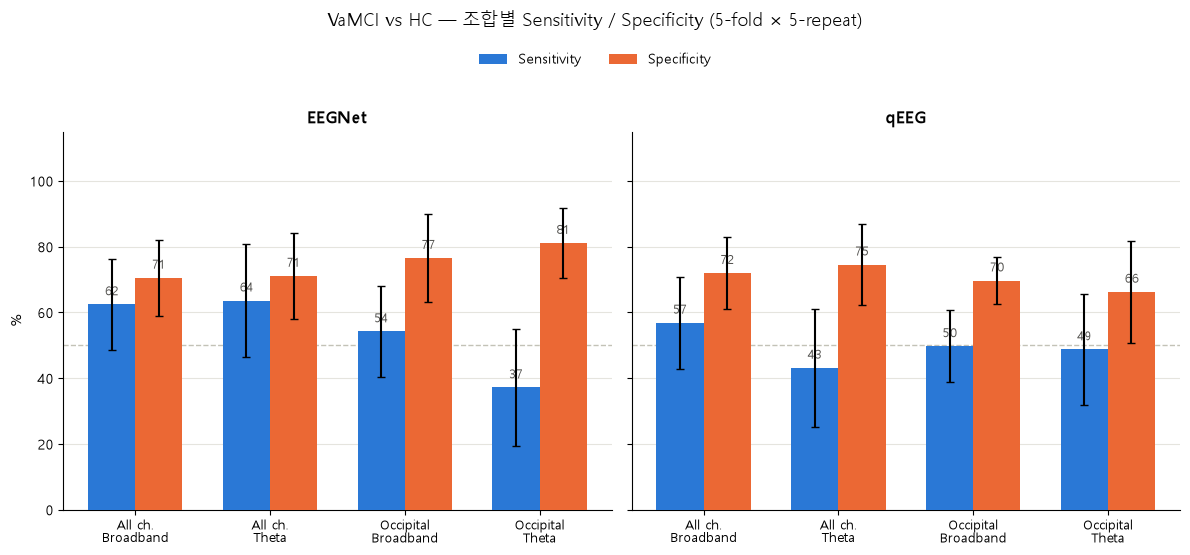

In [3]:
"""
VaMCI-HC (MCI_vascular vs HC) — 민감도/특이도/정밀도 비교 표 + 시각화
ablation_summary_vamci_hc_full_remaining.json 하나만 사용 (4조합의 AUC/Acc/F1/Sens/Spec이
전부 같은 5-fold × 5-repeat 실행에서 나온 값이라 서로 섞이지 않음 — 예전 3-fold 스크리닝
결과는 여기서 안 씀)

Precision(%)은 저장된 요약 파일에 없어서, 같은 폴더의 fold별 원본 json(ablation_eegnet/qeeg_
vamci_hc_full_{combo}.json)을 다시 읽어 fold마다 Accuracy/Sensitivity/Specificity/n_test_subjects
네 값으로 confusion matrix(TP/FP/TN/FN)를 역산해서 계산함(재학습 없이 이미 저장된 값만으로 유도 —
2x2 confusion matrix는 이 네 값으로 유일하게 결정됨). 검증 결과 전부 정수 카운트로 깔끔하게 풀림
(residual ~1e-13, 부동소수점 오차 수준).
"""
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---------------- 0) 한글 폰트 ----------------
for fname in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if any(fname in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = fname
        break
plt.rcParams['axes.unicode_minus'] = False

# ---------------- 1) 데이터 로딩 ----------------
DATA_ROOT = "C:/eeg_research/Vascular_Subset/"
SUMMARY_PATH = DATA_ROOT + 'ablation_summary_vamci_hc_full_remaining.json'

with open(SUMMARY_PATH, encoding='utf-8') as f:
    summary = json.load(f)['results']

COMBO_ORDER = ['all_broadband', 'all_theta', 'occipital_broadband', 'occipital_theta']
COMBO_LABEL = {
    'all_broadband': 'All ch.\nBroadband',
    'all_theta': 'All ch.\nTheta',
    'occipital_broadband': 'Occipital\nBroadband',
    'occipital_theta': 'Occipital\nTheta',
}

# ---------------- 1-1) fold별 원본에서 Precision 역산 ----------------
def precision_stats(model_key, combo):
    path = DATA_ROOT + f'ablation_{model_key}_vamci_hc_full_{combo}.json'
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    precisions = []
    for fold in d['folds']:
        acc, sens, spec = fold['subj_acc'], fold['subj_sensitivity'], fold['subj_specificity']
        total = fold['n_test_subjects']
        if sens == spec:
            continue  # 양성/음성 그룹이 분리 안 돼 유일해 없음 (지금 데이터엔 없음)
        n_pos = round(total * (acc - spec) / (sens - spec))
        n_neg = total - n_pos
        tp = round(sens * n_pos)
        tn = round(spec * n_neg)
        fp = n_neg - tn
        if tp + fp == 0:
            continue
        precisions.append(tp / (tp + fp))
    precisions = np.array(precisions)
    return precisions.mean(), precisions.std()

# ---------------- 2) 표(long-format) ----------------
rows = []
for combo in COMBO_ORDER:
    for model_key, model_label in [('eegnet', 'EEGNet'), ('qeeg', 'qEEG')]:
        m = summary[combo][model_key]
        prec_mean, prec_std = precision_stats(model_key, combo)
        rows.append({
            'combo': combo, 'combo_label': COMBO_LABEL[combo], 'model': model_label,
            'AUC': m['window_auc_mean'], 'AUC_std': m['window_auc_std'],
            'Accuracy': m['subj_acc_mean'], 'Accuracy_std': m['subj_acc_std'],
            'Precision': prec_mean, 'Precision_std': prec_std,
            'Macro_F1': m['subj_macro_f1_mean'], 'Macro_F1_std': m['subj_macro_f1_std'],
            'Sensitivity': m['subj_sensitivity_mean'], 'Sensitivity_std': m['subj_sensitivity_std'],
            'Specificity': m['subj_specificity_mean'], 'Specificity_std': m['subj_specificity_std'],
        })
df = pd.DataFrame(rows)

def fmt(row, col):
    return f"{row[col]*100:.1f}±{row[f'{col}_std']*100:.1f}"

table = pd.DataFrame({
    '조합': df['combo_label'].str.replace('\n', ' '),
    '모델': df['model'],
    'AUC(%)': df.apply(lambda r: fmt(r, 'AUC'), axis=1),
    'Accuracy(%)': df.apply(lambda r: fmt(r, 'Accuracy'), axis=1),
    'Precision(%)': df.apply(lambda r: fmt(r, 'Precision'), axis=1),
    'Sensitivity(%)': df.apply(lambda r: fmt(r, 'Sensitivity'), axis=1),
    'Specificity(%)': df.apply(lambda r: fmt(r, 'Specificity'), axis=1),
    'Macro F1(%)': df.apply(lambda r: fmt(r, 'Macro_F1'), axis=1),
})
print(table.to_string(index=False))
table.to_csv(DATA_ROOT + 'vamci_hc_sens_spec_table.csv', index=False, encoding='utf-8-sig')

# ---------------- 3) 시각화 ----------------
COLOR_SENS = '#2a78d6'   # blue
COLOR_SPEC = '#eb6834'   # orange

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, model_label in zip(axes, ['EEGNet', 'qEEG']):
    sub = df[df['model'] == model_label].set_index('combo_label').loc[
        [COMBO_LABEL[c] for c in COMBO_ORDER]
    ]
    x = range(len(sub))
    width = 0.35

    bars_sens = ax.bar([i - width/2 for i in x], sub['Sensitivity'] * 100, width,
                        yerr=sub['Sensitivity_std'] * 100, capsize=3,
                        color=COLOR_SENS, label='Sensitivity', zorder=3)
    bars_spec = ax.bar([i + width/2 for i in x], sub['Specificity'] * 100, width,
                        yerr=sub['Specificity_std'] * 100, capsize=3,
                        color=COLOR_SPEC, label='Specificity', zorder=3)

    for bars in (bars_sens, bars_spec):
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
                     f'{b.get_height():.0f}', ha='center', va='bottom',
                     fontsize=9, color='#52514e')

    ax.set_xticks(list(x))
    ax.set_xticklabels(sub.index, fontsize=9)
    ax.set_title(model_label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.axhline(50, color='#c3c2b7', linewidth=1, linestyle='--', zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#e5e4de', linewidth=0.8, zorder=0)

axes[0].set_ylabel('%', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle('VaMCI vs HC — 조합별 Sensitivity / Specificity (5-fold × 5-repeat)', fontsize=13, y=1.10)
plt.tight_layout()
plt.savefig(DATA_ROOT + 'vamci_hc_sens_spec_chart.png', dpi=200, bbox_inches='tight')
plt.show()


### 4-12. EEGNet vs qEEG 통계적 유의성 검정 (Wilcoxon signed-rank + rank-biserial 효과크기)

VaMCI-HC 4개 핵심 조합(all/broadband, all/theta, occipital/broadband, occipital/theta)에서
EEGNet과 qEEG 중 어느 쪽이 통계적으로 유의하게 더 나은지 검정.

**Mann-Whitney U가 아니라 Wilcoxon signed-rank test를 쓴 이유**: 참고한 포스터(KCC2026)는
서로 다른 두 피험자 그룹(aMCI vs naMCI)을 비교했기 때문에 독립표본 검정(Mann-Whitney U)이 맞지만,
여기서는 **같은 CV fold(같은 학습/테스트 분할)에서** EEGNet과 qEEG를 나란히 돌린 것이므로 두 모델의
fold별 성능이 서로 짝지어진(paired) 데이터임 — 이 경우 paired-sample 검정인 Wilcoxon signed-rank test가
통계적으로 올바름. 효과크기는 matched-pairs rank-biserial correlation(-1~1)으로 계산.

새로 학습을 재실행할 필요 없이, 이미 저장된 4개 조합의 fold별 원본 AUC(5-fold×5-repeat=25쌍)를 그대로 사용.

In [11]:
"""
EEGNet vs qEEG — VaMCI-HC 4개 핵심 조합 통계적 유의성 검정 + 효과크기
ablation_eegnet_vamci_hc_full_{combo}.json / ablation_qeeg_vamci_hc_full_{combo}.json의
fold별 원본 window_auc를 같은 (repeat, fold)끼리 짝지어 Wilcoxon signed-rank test 수행.
효과크기는 matched-pairs rank-biserial correlation.
"""
import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

DATA_ROOT = "C:/eeg_research/Vascular_Subset/"
COMBO_ORDER = ['all_broadband', 'all_theta', 'occipital_broadband', 'occipital_theta']
COMBO_LABEL = {
    'all_broadband': 'All ch. Broadband', 'all_theta': 'All ch. Theta',
    'occipital_broadband': 'Occipital Broadband', 'occipital_theta': 'Occipital Theta',
}
METRIC = 'window_auc'

def load_fold_values(model, combo, metric=METRIC):
    path = DATA_ROOT + f'ablation_{model}_vamci_hc_full_{combo}.json'
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    folds = sorted(d['folds'], key=lambda x: (x['repeat'], x['fold']))
    return np.array([f[metric] for f in folds])

def matched_pairs_rank_biserial(x, y):
    diff = np.asarray(x) - np.asarray(y)
    diff = diff[diff != 0]
    ranks = np.abs(diff).argsort().argsort() + 1
    w_pos = ranks[diff > 0].sum()
    w_neg = ranks[diff < 0].sum()
    return (w_pos - w_neg) / (w_pos + w_neg)

rows = []
for combo in COMBO_ORDER:
    eeg = load_fold_values('eegnet', combo)
    qeeg = load_fold_values('qeeg', combo)
    stat, p = wilcoxon(eeg, qeeg)
    r = matched_pairs_rank_biserial(eeg, qeeg)
    rows.append({
        '조합': COMBO_LABEL[combo],
        'EEGNet AUC': f'{eeg.mean():.3f}', 'qEEG AUC': f'{qeeg.mean():.3f}',
        'Wilcoxon p': f'{p:.4f}', 'rank-biserial r': f'{r:.3f}',
        '유의성(p<.05)': 'Yes' if p < 0.05 else 'No',
        'n_pairs': len(eeg),
    })

stats_table = pd.DataFrame(rows)
print(stats_table.to_string(index=False))
stats_table.to_csv(DATA_ROOT + 'vamci_hc_eegnet_vs_qeeg_stats.csv', index=False, encoding='utf-8-sig')


                 조합 EEGNet AUC qEEG AUC Wilcoxon p rank-biserial r 유의성(p<.05)  n_pairs
  All ch. Broadband      0.731    0.684     0.0219           0.520        Yes       25
      All ch. Theta      0.737    0.601     0.0000           1.000        Yes       25
Occipital Broadband      0.727    0.657     0.0000           0.951        Yes       25
    Occipital Theta      0.619    0.562     0.0000           1.000        Yes       25


### 4-13. 실행: VaMCI vs HC — 채널 영역×주파수 대역 sweep (11개 조합, 5-fold × 5-repeat 풀세팅)

포스터 참고 파일(`ftdnamci_poster_EM.pptx`)의 "Classification Accuracy by Brain Region and
Frequency Band" 그래프와 같은 취지로, 채널 영역별·주파수 대역별 비교를 위한 sweep.

**처음엔 3-fold×1-repeat 스크리닝으로 계획했었는데, Cell 4-10(4개 핵심 조합 풀세팅)의 실제 저장
시각(`saved_at`)을 직접 대조해보니 이 컴퓨터 기준 19채널 조합은 약 90분, 채널 수 적은 조합(후두부 등)은
약 46분이면 끝난다는 게 확인됨(노트북에 적혀 있던 "조합당 9~11시간"은 실측과 맞지 않는 과거 추정치였음
— 실측 기준으로 갱신). 이 속도면 11개 조합 전부 풀세팅으로 돌려도 감당 가능하다고 판단해서 **스크리닝
없이 바로 5-fold × 5-repeat × 100epoch 풀세팅으로 변경**.

11개 조합 중 3개(`all/broadband`, `occipital/broadband`, `all/theta`)는 Cell 4-10에서 이미 이
설정 그대로 완료돼 있으므로 **재실행하지 않고 건너뜀** — 나머지 8개(`frontal/central/temporal/
parietal_broadband` + `all_delta/alpha/beta/gamma`)만 새로 실행.

**`run_tag`는 Cell 4-10과 동일하게 `'vamci_hc_full'`을 그대로 사용** — 조합별 파일명이
`ablation_eegnet_vamci_hc_full_{region}_{band}.json` 형태로 저장되는데, 이번에 새로 도는 8개 조합의
`combo_key`가 기존 3개와 절대 겹치지 않으므로(서로 다른 region/band 조합) 파일 덮어쓰기 위험 없이
**11개 전부 같은 네이밍 규칙으로 통일**됨 — 이후 시각화 셀(4-14)에서 조합별 파일을 따로따로 읽어오면 됨.

**예상 소요 시간**: 19채널 유지 조합(delta/alpha/beta/gamma) 4개 × 약 90분 + 채널 수가 적은 region
조합(frontal/central/temporal/parietal) 4개 × 약 50~80분 ≈ **총 10~11시간 내외로 추정**(실측 기반
추정이지만 정확한 값은 아님 — 조합마다 채널 수·윈도우 수가 달라 실제로는 차이가 있을 수 있음).

In [12]:
EXPERIMENTS_11_VAMCI_HC = [('all', 'broadband')]
EXPERIMENTS_11_VAMCI_HC += [(region, 'broadband') for region in CHANNEL_REGIONS if region != 'all']
EXPERIMENTS_11_VAMCI_HC += [('all', band) for band in BANDS if band != 'broadband']

# Cell 4-10에서 이미 5-fold x 5-repeat 풀세팅으로 완료된 3개 조합은 재실행하지 않고 건너뜀
ALREADY_DONE_FULL = {('all', 'broadband'), ('occipital', 'broadband'), ('all', 'theta')}
EXPERIMENTS_REMAINING = [exp for exp in EXPERIMENTS_11_VAMCI_HC if exp not in ALREADY_DONE_FULL]
print(f'전체 11개 조합 중 이미 완료된 {len(ALREADY_DONE_FULL)}개 제외, {len(EXPERIMENTS_REMAINING)}개 새로 실행: {EXPERIMENTS_REMAINING}')

results_vamci_hc_full11_remaining = run_ablation_suite(
    pair_vamci_hc, ch_names3,
    experiments=EXPERIMENTS_REMAINING,
    n_folds=5, n_repeats=5, epochs=100,
    do_qeeg=True,
    run_tag='vamci_hc_full',  # Cell 4-10과 동일 run_tag — combo_key가 겹치지 않아 기존 3개 파일 덮어쓰기 위험 없음
    summary_save_path=DATA_ROOT + 'ablation_summary_vamci_hc_full11_new8.json',
)


전체 11개 조합 중 이미 완료된 3개 제외, 8개 새로 실행: [('frontal', 'broadband'), ('central', 'broadband'), ('temporal', 'broadband'), ('parietal', 'broadband'), ('all', 'delta'), ('all', 'alpha'), ('all', 'beta'), ('all', 'gamma')]

===== 조합 시작: region=frontal, band=broadband =====
[frontal_broadband] 총 윈도우 수: 21164, n_channels=7, n_samples=1000
[eegnet_vamci_hc_full_frontal_broadband][rep 1/5][fold 1/5] AUC=0.725 subj_acc=0.615 subj_f1=0.606 sens=0.500 spec=0.714 (train=14247 val=2678 test=4239 windows, test_subj=26) -> C:/eeg_research/Vascular_Subset/ablation_eegnet_vamci_hc_full_frontal_broadband.json
[eegnet_vamci_hc_full_frontal_broadband][rep 1/5][fold 2/5] AUC=0.623 subj_acc=0.593 subj_f1=0.590 sens=0.692 spec=0.500 (train=14422 val=2528 test=4214 windows, test_subj=27) -> C:/eeg_research/Vascular_Subset/ablation_eegnet_vamci_hc_full_frontal_broadband.json
[eegnet_vamci_hc_full_frontal_broadband][rep 1/5][fold 3/5] AUC=0.604 subj_acc=0.600 subj_f1=0.566 sens=0.364 spec=0.786 (train=14445 val=2469

### 4-14. 결과 시각화 — 채널 영역별 / 주파수 대역별 Accuracy 비교 (5-fold × 5-repeat, 포스터용)

Cell 4-13에서 저장한 11개 조합의 개별 결과 파일(`ablation_eegnet_vamci_hc_full_{combo}.json`)을
조합별로 직접 읽어서 두 패널로 시각화: 왼쪽은 region축(broadband 고정, all/frontal/central/temporal/
parietal/occipital 비교), 오른쪽은 band축(all channel 고정, broadband/delta/theta/alpha/beta/gamma
비교). EEGNet Accuracy 기준.

이제 전부 5-fold × 5-repeat 풀세팅 결과라 **최종 보고 수치로 써도 됨** (스크리닝 아님). 다만 초록에
보고한 4개 핵심 조합의 정확한 텍스트 수치는 그대로 Cell 4-11의 표를 사용할 것 — 이 차트는 그 4개 조합을
포함한 11개 전체를 한눈에 비교하는 보조 시각 자료.

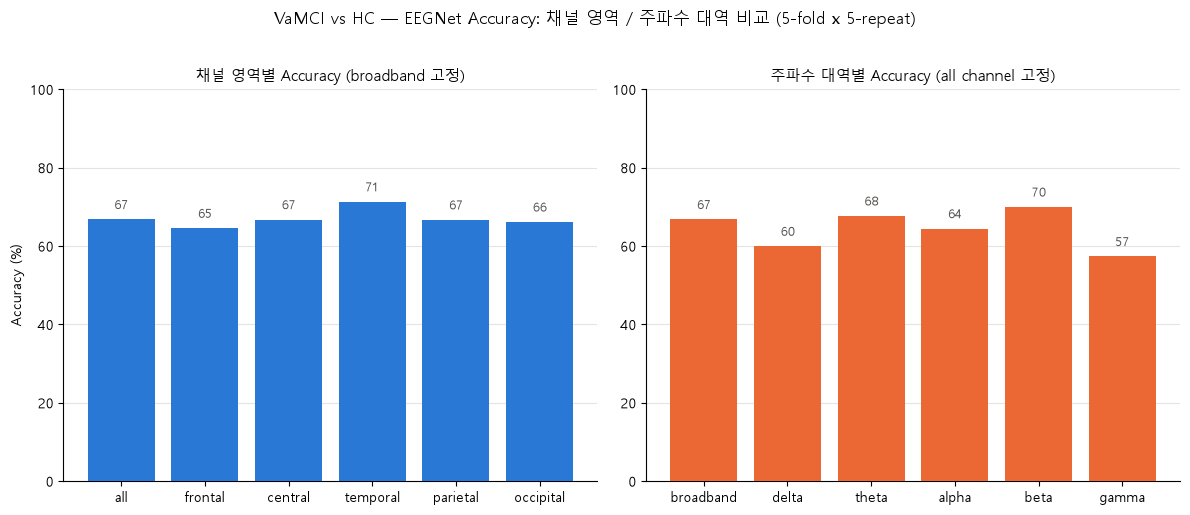

In [13]:
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for fname in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if any(fname in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = fname
        break
plt.rcParams['axes.unicode_minus'] = False

REGION_ORDER = ['all', 'frontal', 'central', 'temporal', 'parietal', 'occipital']
BAND_ORDER = ['broadband', 'delta', 'theta', 'alpha', 'beta', 'gamma']

def load_acc_mean(combo, model='eegnet'):
    path = DATA_ROOT + f'ablation_{model}_vamci_hc_full_{combo}.json'
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    accs = [fold['subj_acc'] for fold in d['folds']]
    return sum(accs) / len(accs) * 100

region_acc = [load_acc_mean(f'{r}_broadband') for r in REGION_ORDER]
band_acc = [load_acc_mean(f'all_{b}') for b in BAND_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(REGION_ORDER, region_acc, color='#2a78d6', zorder=3)
axes[0].set_title('채널 영역별 Accuracy (broadband 고정)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', color='#e5e4de', linewidth=0.8, zorder=0)
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(region_acc):
    axes[0].text(i, v + 2, f'{v:.0f}', ha='center', va='bottom', fontsize=9, color='#52514e')

axes[1].bar(BAND_ORDER, band_acc, color='#eb6834', zorder=3)
axes[1].set_title('주파수 대역별 Accuracy (all channel 고정)', fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', color='#e5e4de', linewidth=0.8, zorder=0)
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(band_acc):
    axes[1].text(i, v + 2, f'{v:.0f}', ha='center', va='bottom', fontsize=9, color='#52514e')

fig.suptitle('VaMCI vs HC — EEGNet Accuracy: 채널 영역 / 주파수 대역 비교 (5-fold x 5-repeat)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DATA_ROOT + 'vamci_hc_full11_region_band_chart.png', dpi=200, bbox_inches='tight')
plt.show()


### 4-15. 채널/대역 축소가 성능을 유의하게 떨어뜨리는지 검정 (paired Wilcoxon)

**연구 핵심 주장("후두부 2채널만으로도 19채널에 준하는 성능")을 통계적으로 직접 뒷받침하는 검정.**

Cell 4-10에서 4개 조합(all/broadband, all/theta, occipital/broadband, occipital/theta)을 전부
**같은 `run_ablation_suite` 호출 안에서, 같은 `random_state=rep`로 StratifiedGroupKFold를 나눴기 때문에**
(Cell 4-4 `run_cv`의 `StratifiedGroupKFold(..., random_state=rep)` 참고 — region/band와 무관하게 rep에만
의존) 조합이 달라도 같은 fold(같은 피험자 분할)를 쓴 것과 같음. 따라서 조합 간 비교도 EEGNet vs qEEG
비교와 마찬가지로 **짝지어진(paired) 비교**가 통계적으로 타당함.

- **채널 축소 검정**: `all_*` vs `occipital_*` (같은 대역끼리) — 19채널→2채널로 줄였을 때 성능이 유의하게
  떨어지는지. **유의하지 않다면(p≥.05) 오히려 좋은 결과** — "채널을 줄여도 성능 차이가 없다"는 근거가 됨.
- **대역 선택 검정**: `*_broadband` vs `*_theta` (같은 채널끼리) — broadband 대신 theta만 써도 되는지.
- **Chance level 대비 검정**: AUC=0.5(무작위 추측)와 비교 — 분류기가 실제로 유의미하게 학습됐는지 확인.

전부 재실행 없이 기존 fold 원본 데이터로 계산됨.

In [14]:
"""
채널 축소(19ch→occipital 2ch) / 대역 선택(broadband→theta) 유의성 검정 + chance-level 검정.
Cell 4-12와 동일한 이유로 Wilcoxon signed-rank(paired) 사용 — 조합이 달라도 같은 rep의 fold는
같은 피험자 분할이라 짝지어진 비교가 타당함.
"""
import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

DATA_ROOT = "C:/eeg_research/Vascular_Subset/"

def load_fold_values(model, combo, metric='window_auc'):
    path = DATA_ROOT + f'ablation_{model}_vamci_hc_full_{combo}.json'
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    folds = sorted(d['folds'], key=lambda x: (x['repeat'], x['fold']))
    return np.array([f[metric] for f in folds])

def matched_pairs_rank_biserial(x, y):
    diff = np.asarray(x) - np.asarray(y)
    diff = diff[diff != 0]
    ranks = np.abs(diff).argsort().argsort() + 1
    w_pos = ranks[diff > 0].sum()
    w_neg = ranks[diff < 0].sum()
    return (w_pos - w_neg) / (w_pos + w_neg)

# ---- 1) 채널 축소 검정: all_* vs occipital_* ----
rows = []
for model in ['eegnet', 'qeeg']:
    for band in ['broadband', 'theta']:
        full = load_fold_values(model, f'all_{band}')
        occ = load_fold_values(model, f'occipital_{band}')
        stat, p = wilcoxon(full, occ)
        r = matched_pairs_rank_biserial(full, occ)
        rows.append({'검정': '채널 축소 (19ch vs 후두부 2ch)', '모델': model, '대역': band,
                      '19ch AUC': f'{full.mean():.3f}', '2ch AUC': f'{occ.mean():.3f}',
                      'p': f'{p:.4f}', 'r': f'{r:+.3f}',
                      '해석': '성능 차이 없음(축소해도 안전)' if p >= 0.05 else '유의한 차이 있음'})

# ---- 2) 대역 선택 검정: broadband vs theta ----
for model in ['eegnet', 'qeeg']:
    for region in ['all', 'occipital']:
        bb = load_fold_values(model, f'{region}_broadband')
        th = load_fold_values(model, f'{region}_theta')
        stat, p = wilcoxon(bb, th)
        r = matched_pairs_rank_biserial(bb, th)
        rows.append({'검정': 'broadband vs theta', '모델': model, '대역': region,
                      '19ch AUC': f'{bb.mean():.3f}', '2ch AUC': f'{th.mean():.3f}',
                      'p': f'{p:.4f}', 'r': f'{r:+.3f}',
                      '해석': '차이 없음' if p >= 0.05 else '유의한 차이 있음'})

reduction_table = pd.DataFrame(rows)
reduction_table.columns = ['검정', '모델', '조건', 'A AUC', 'B AUC', 'p', 'r', '해석']
print(reduction_table.to_string(index=False))
reduction_table.to_csv(DATA_ROOT + 'vamci_hc_channel_band_reduction_stats.csv', index=False, encoding='utf-8-sig')

print()

# ---- 3) chance level(AUC=0.5) 대비 검정 ----
chance_rows = []
for model in ['eegnet', 'qeeg']:
    for combo in ['all_broadband', 'all_theta', 'occipital_broadband', 'occipital_theta']:
        vals = load_fold_values(model, combo)
        stat, p = wilcoxon(vals - 0.5)
        chance_rows.append({'모델': model, '조합': combo, 'AUC 평균': f'{vals.mean():.3f}', 'p (vs 0.5)': f'{p:.2e}'})
chance_table = pd.DataFrame(chance_rows)
print(chance_table.to_string(index=False))
chance_table.to_csv(DATA_ROOT + 'vamci_hc_vs_chance_stats.csv', index=False, encoding='utf-8-sig')


                     검정     모델        조건 A AUC B AUC      p      r                해석
채널 축소 (19ch vs 후두부 2ch) eegnet broadband 0.731 0.727 0.7712 +0.071 성능 차이 없음(축소해도 안전)
채널 축소 (19ch vs 후두부 2ch) eegnet     theta 0.737 0.619 0.0000 +1.000         유의한 차이 있음
채널 축소 (19ch vs 후두부 2ch)   qeeg broadband 0.684 0.657 0.0013 +0.705         유의한 차이 있음
채널 축소 (19ch vs 후두부 2ch)   qeeg     theta 0.601 0.562 0.0000 +0.883         유의한 차이 있음
     broadband vs theta eegnet       all 0.731 0.737 0.6338 -0.114             차이 없음
     broadband vs theta eegnet occipital 0.727 0.619 0.0000 +1.000         유의한 차이 있음
     broadband vs theta   qeeg       all 0.684 0.601 0.0000 +1.000         유의한 차이 있음
     broadband vs theta   qeeg occipital 0.657 0.562 0.0000 +0.994         유의한 차이 있음

    모델                  조합 AUC 평균 p (vs 0.5)
eegnet       all_broadband  0.731   5.96e-08
eegnet           all_theta  0.737   5.96e-08
eegnet occipital_broadband  0.727   5.96e-08
eegnet     occipital_theta  0.619   1.19e-07
  qeeg   